In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from math import ceil
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from scipy.stats import chi2_contingency, stats
from sklearn.svm import LinearSVR
from sklearn.feature_selection import RFE, VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, RFECV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LassoCV, LinearRegression, Ridge, ElasticNet, HuberRegressor, BayesianRidge, RANSACRegressor, TheilSenRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Import the dataset

In [3]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [4]:
train_df = train_data.copy()
test_df = test_data.copy()

In [5]:
train_df[train_df.duplicated()]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage


In [6]:
train_df.set_index('carID', inplace = True)
test_df.set_index('carID', inplace = True)

# Data Exploration

In [7]:
train_df.shape, test_df.shape

((75973, 13), (32567, 12))

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75973 entries, 69512 to 15795
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           74452 non-null  object 
 1   model           74456 non-null  object 
 2   year            74482 non-null  float64
 3   price           75973 non-null  int64  
 4   transmission    74451 non-null  object 
 5   mileage         74510 non-null  float64
 6   fuelType        74462 non-null  object 
 7   tax             68069 non-null  float64
 8   mpg             68047 non-null  float64
 9   engineSize      74457 non-null  float64
 10  paintQuality%   74449 non-null  float64
 11  previousOwners  74423 non-null  float64
 12  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 8.1+ MB


In [9]:
train_df.isna().sum()

Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

In [10]:
train_df.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


In [11]:
train_df.describe(include=['O'])

,Brand,model,transmission,fuelType
count,74452,74456,74451,74462
unique,72,735,40,34
top,Ford,Focus,Manual,Petrol
freq,14808,6353,38050,37995


In [12]:
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

Altough there are a lot of errors in the data we can observe that are a few dominant values whitin the categorical features:
- Ford, Mercedes and VW are the most represented brands
- Focus, C Class and Fiesta are the most frequent models
- Most cars are Petrol or Diesel
- A large majority of the car have manual transmission

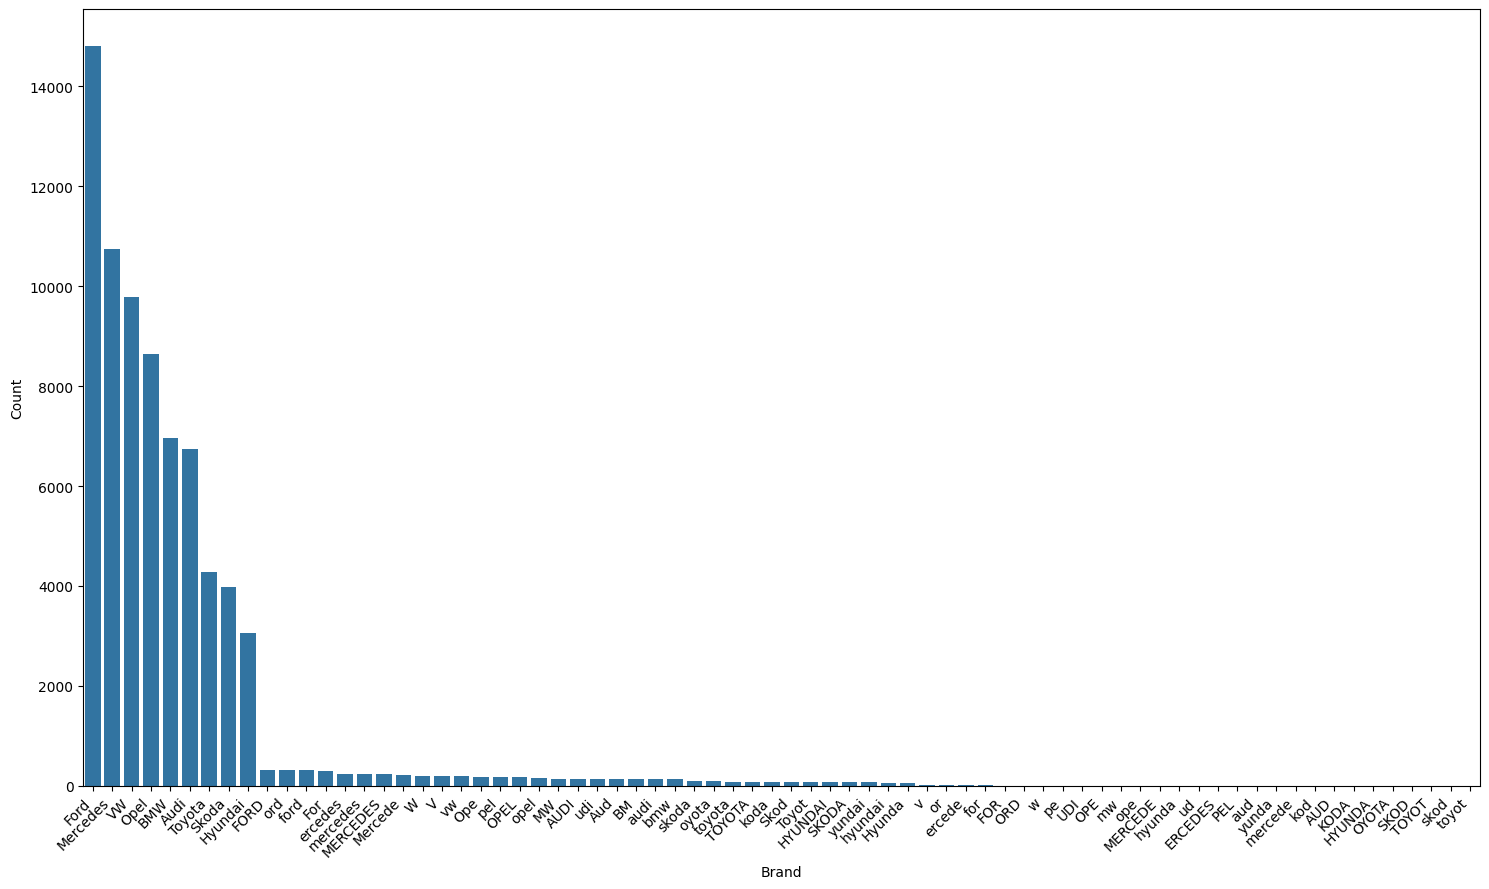

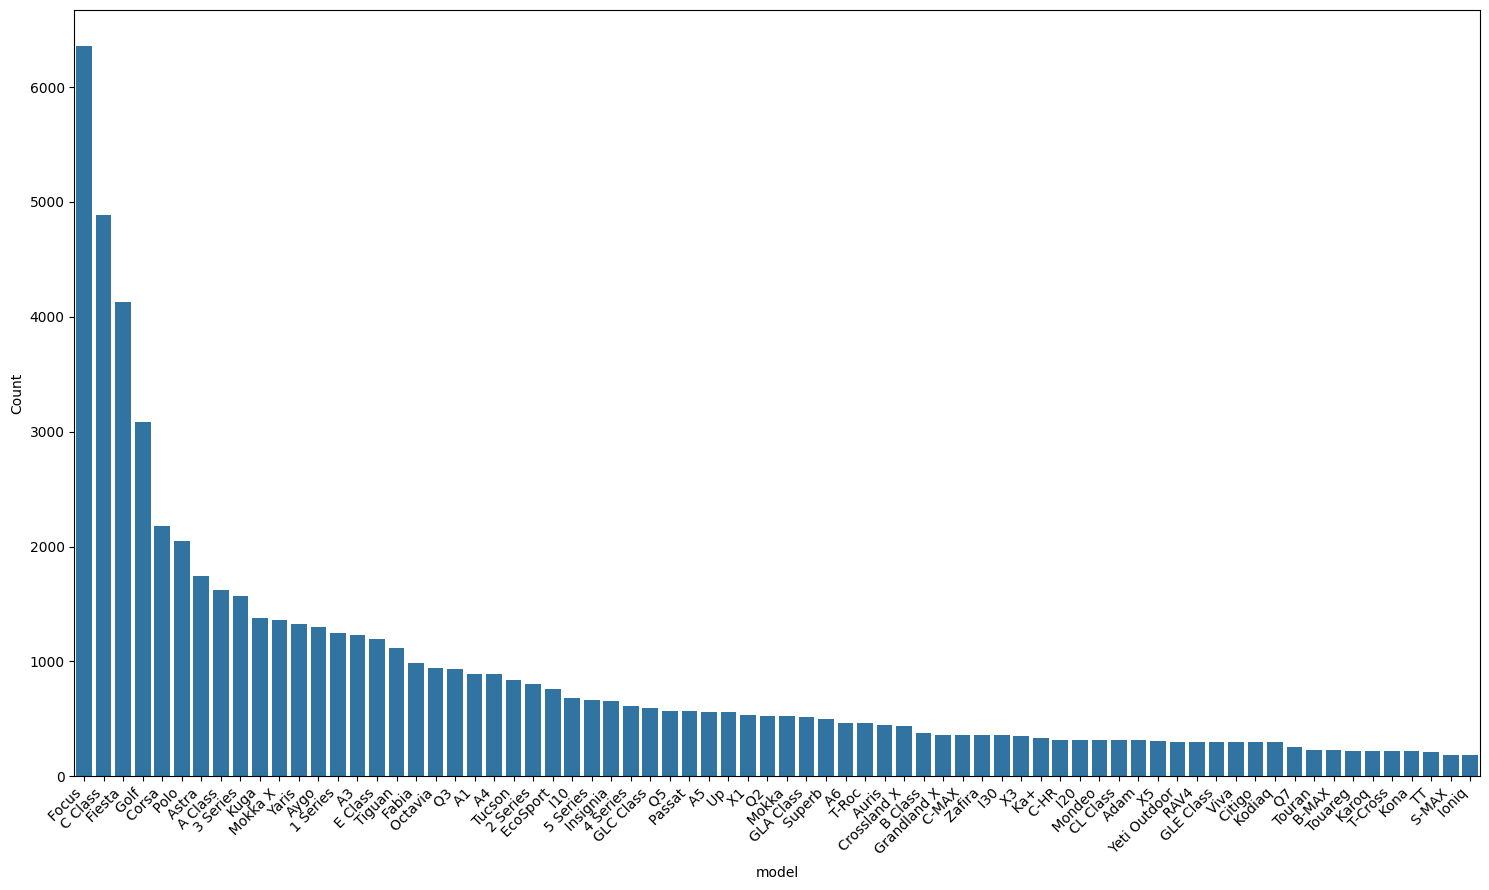

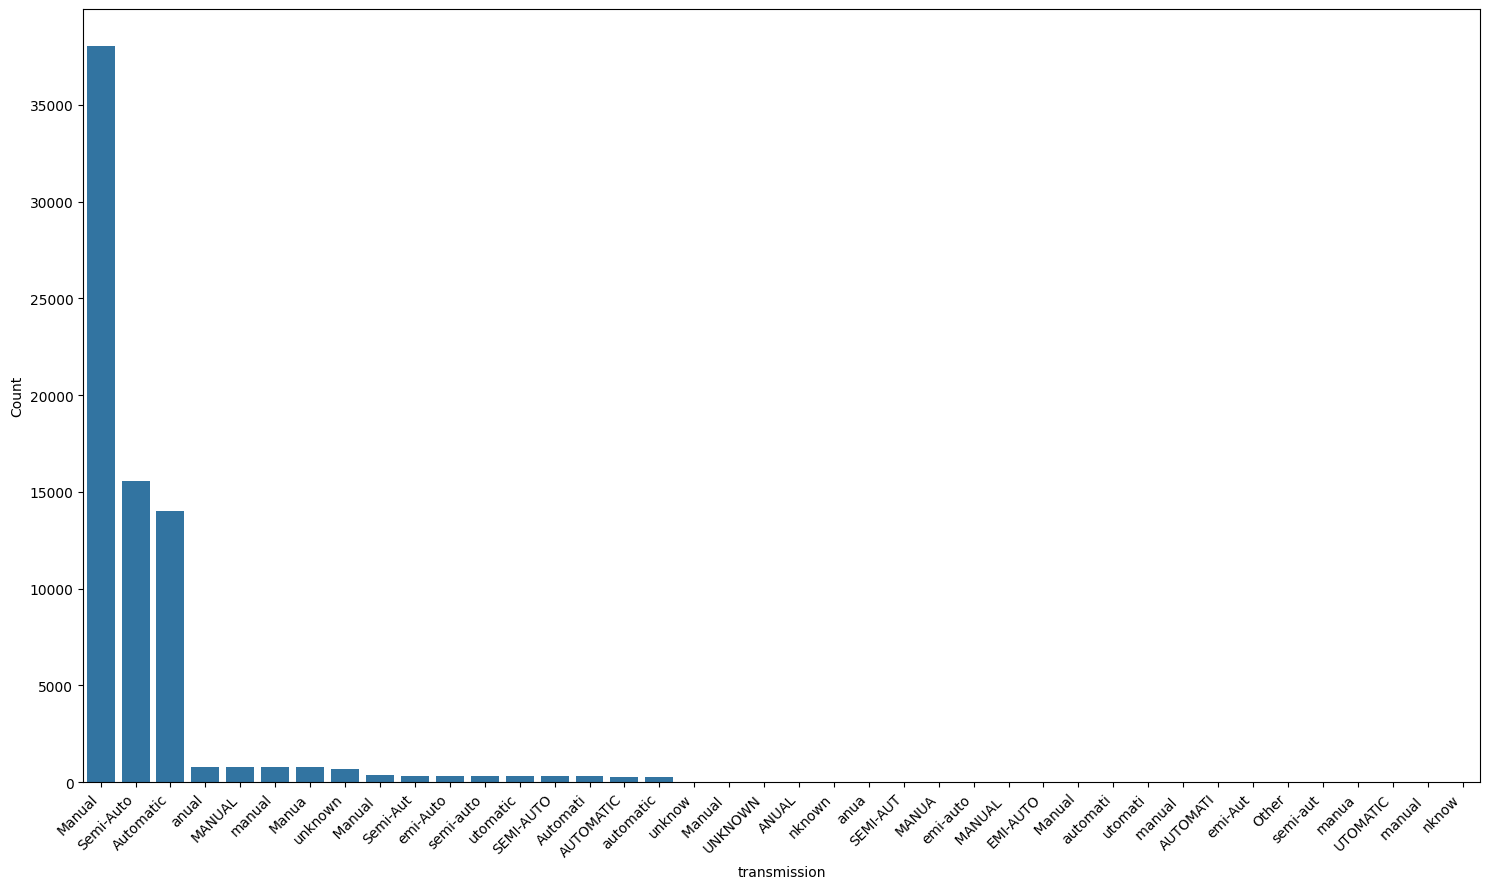

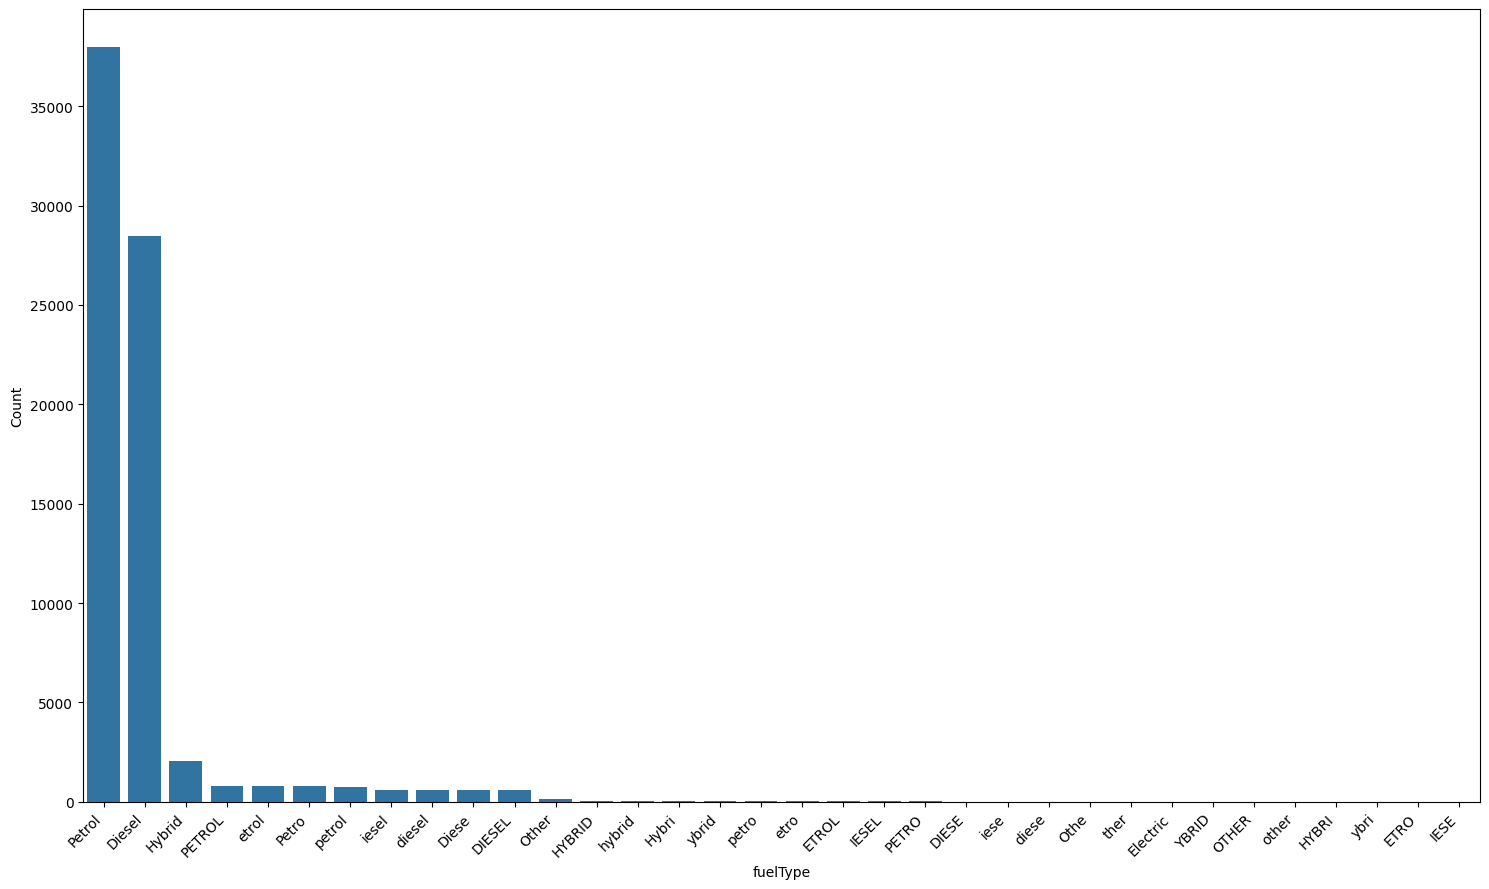

In [13]:
for col in categorical_features:
    top_n = 72
    model_counts = train_df[col].value_counts().nlargest(top_n)

    plt.figure(figsize=(15,9))
    sns.barplot(x=model_counts.index, y=model_counts.values)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(f"{col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In terms of distributions we have a lot of different situations. Before log transformation, price, mileage are considerably right-skewed (which highlights the presence of outliers), while mpg is also slighly right-skewed.Tax is left skewed.

c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\pandas\core\arraylike.py:3

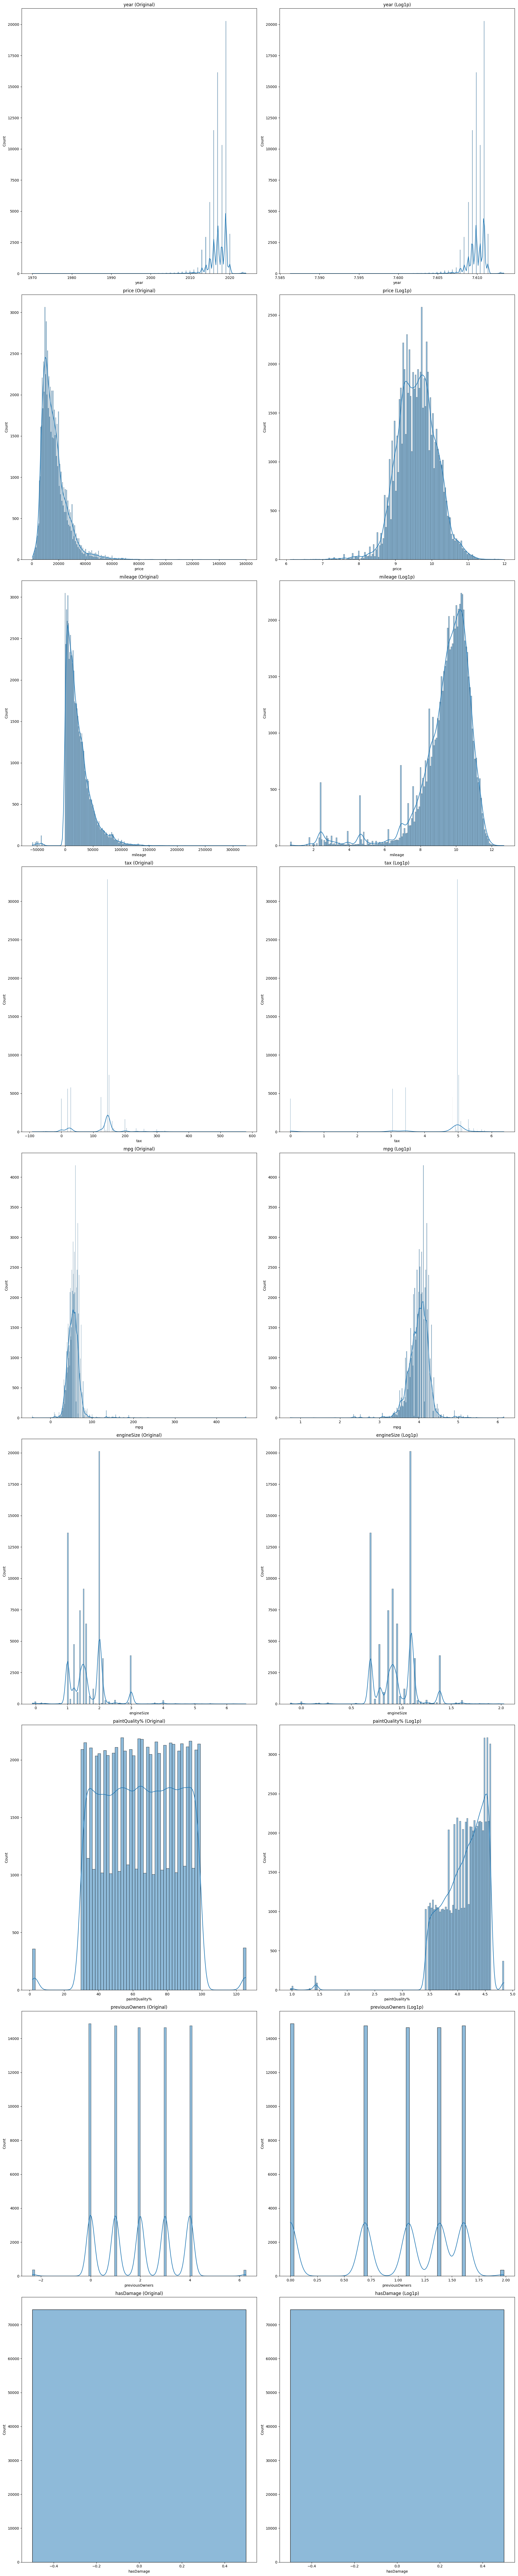

In [14]:
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(20, 11*len(numeric_features)))

for i, col in enumerate(numeric_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} (Original)")
    sns.histplot(np.log1p(train_df[col].dropna()), kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} (Log1p)")

plt.tight_layout()
plt.show()


### Boxplot

All columns except Paint Quality have outliers.
- Tax, mpg, mileage, previous owners have non-sensical values since some of the values are negative. Same with Engine Size with values equaling 0.
- Paint Quality has values above 100% which is also non-sensical
- Price, mileage, tax and mpg have a large number of outliers


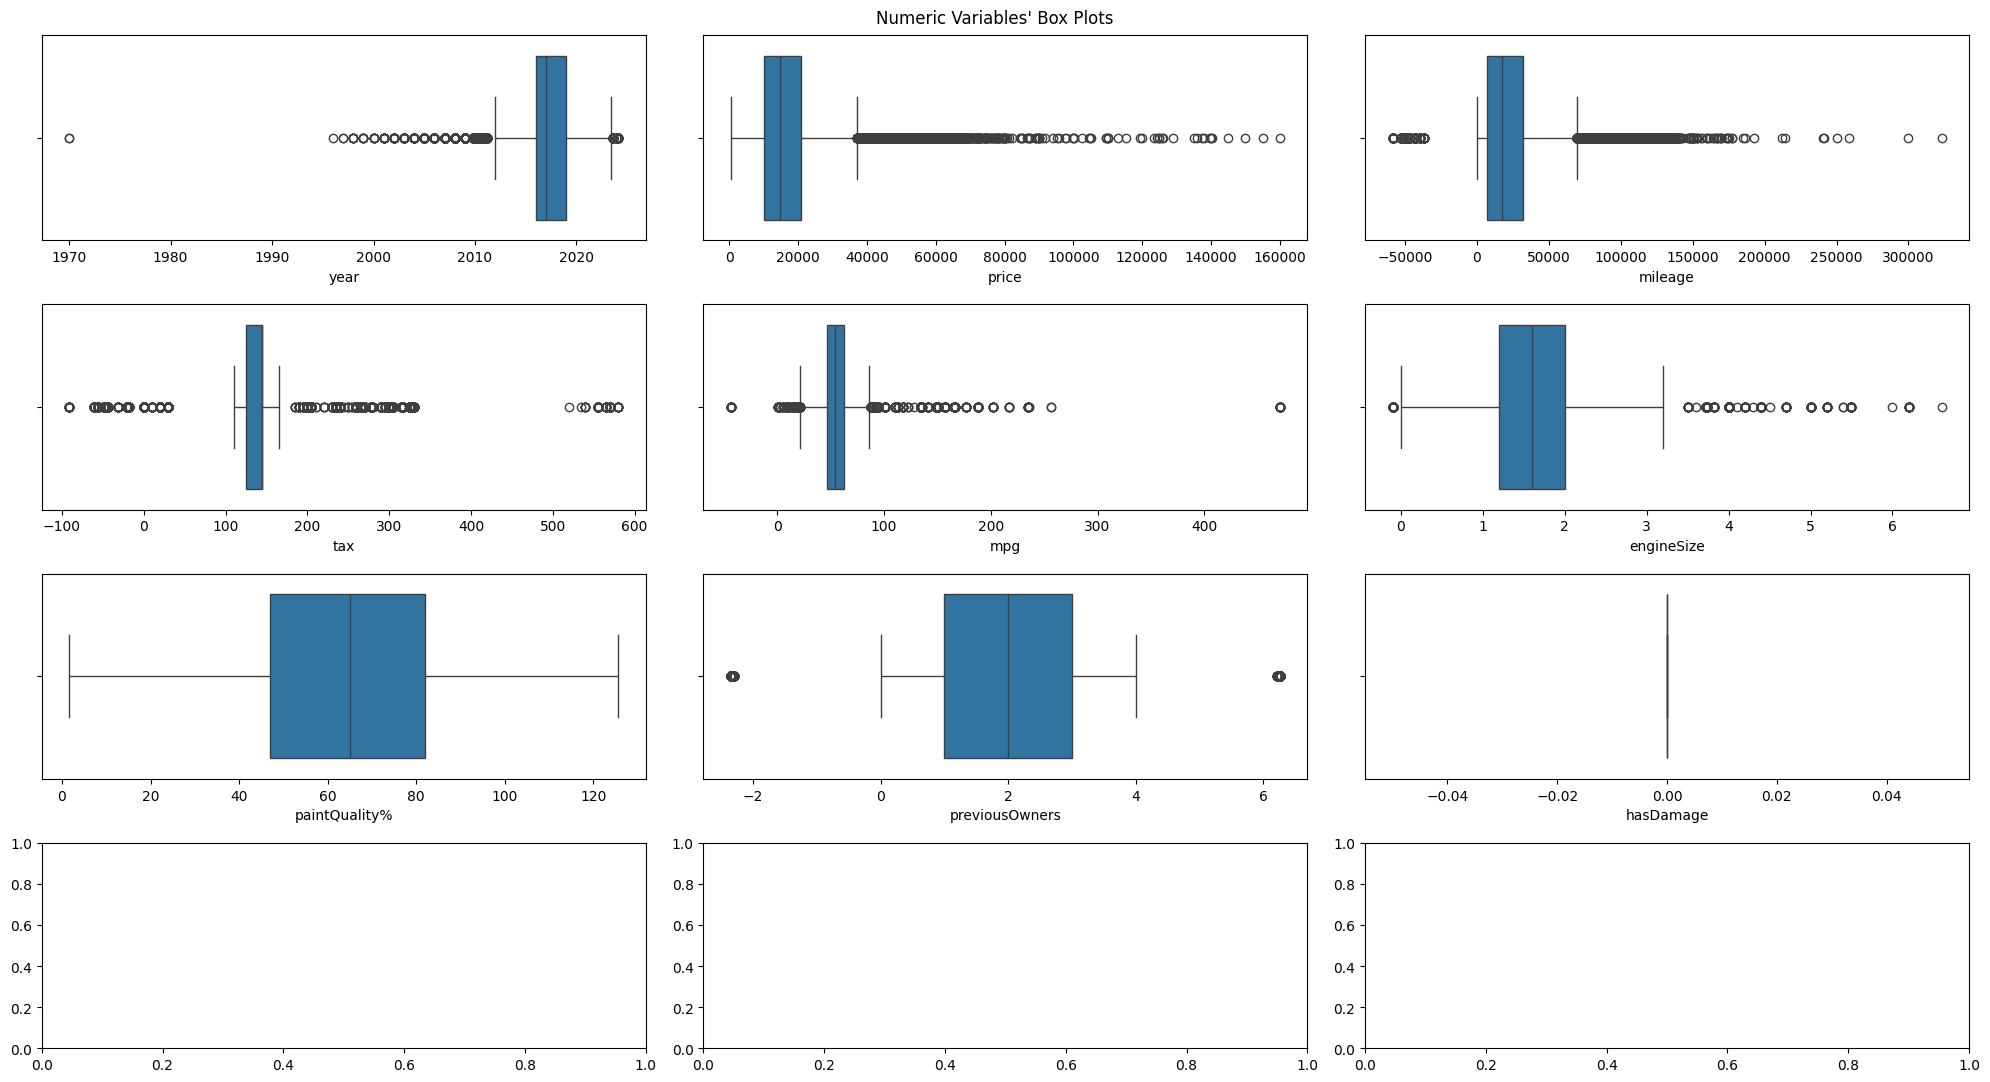

In [15]:
# Define number of subplot rows and columns
sp_rows = 4
sp_cols = ceil(len(numeric_features) / sp_rows)


# Create subplots
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11),
                         tight_layout=True
                        )

# Plot data
# Iterate across axes objects and associate each histogram (hint: use the ax.hist() instead of plt.hist()):
for ax, feat in zip(axes.flatten(), numeric_features): # Notice the zip() function and flatten() method
    sns.boxplot(x=train_df[feat], ax=ax)
    
# Add a centered title to the figure:
title = "Numeric Variables' Box Plots"

plt.suptitle(title)

plt.show()

### Correlation Analysis

There are not any high correlation between features. Mileage and year with -0.67 and price and Engine size with 0.61 are the biggest correlations.

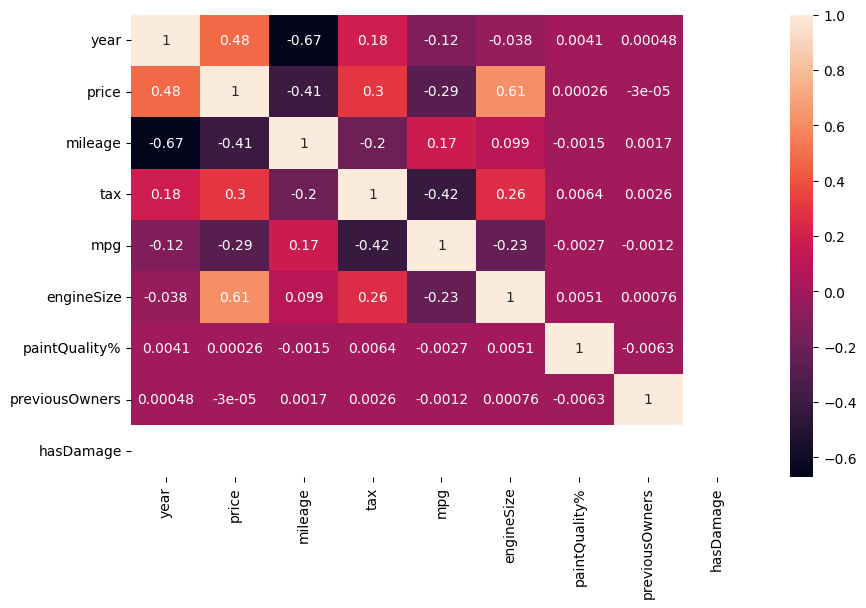

In [16]:
fig = plt.figure(figsize=(10, 6))

# Obtain correlation matrix. 
corr = train_df[numeric_features].corr(method="pearson")

# Plot heatmap of the correlation matrix
sns.heatmap(data=corr, annot=True, )

plt.show()

## Multivariate Analysis

Given our categorical (we will exclude models from this analisys as this features has too many values and too many errors) we will analyze the existence of outliers and the possibility of confirming there are certain characteristics associated with higher or lower prices.
- While considering price vs brand, mercedes and audi have both some of the biggest distributions and also the largest numbers of outliers. Brand like hyundai and skoda are more economical as they have small distributions and their outliers are in some cases cheaper that the higher end some other brands like bmw, audi or mercedes.

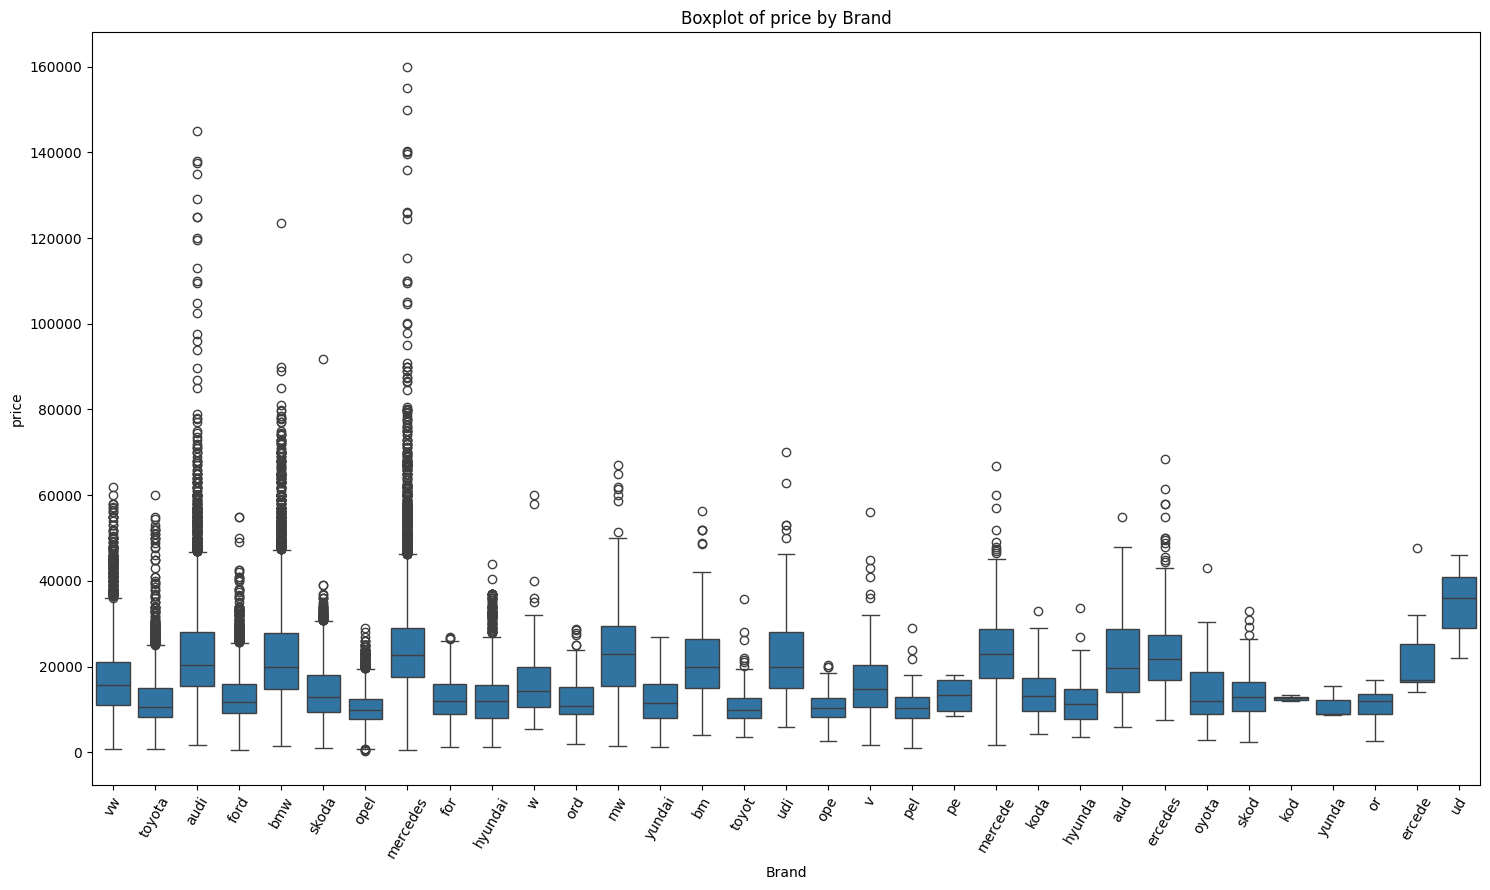

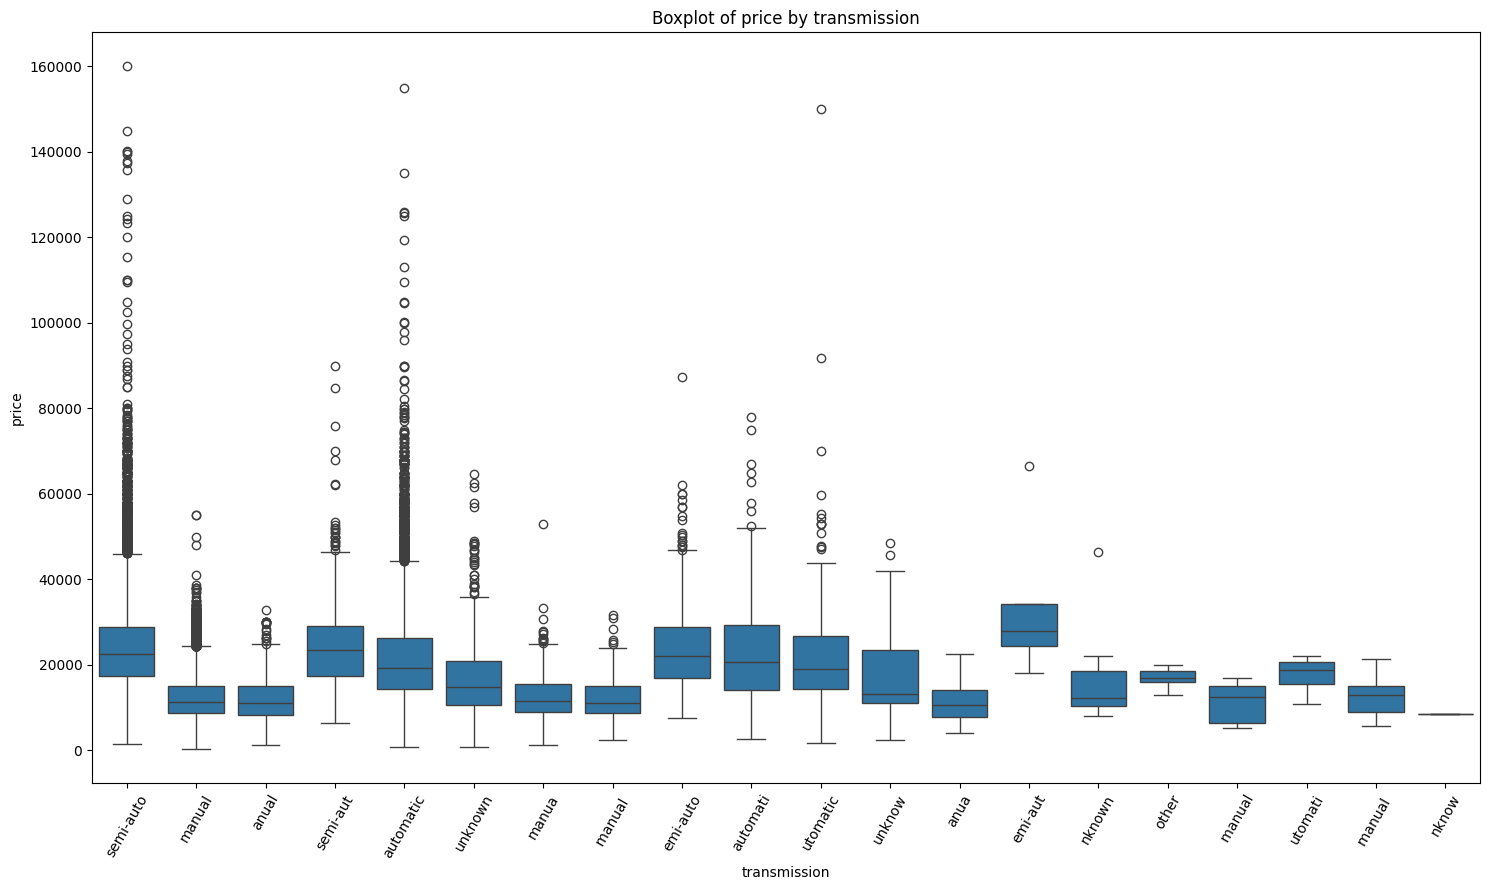

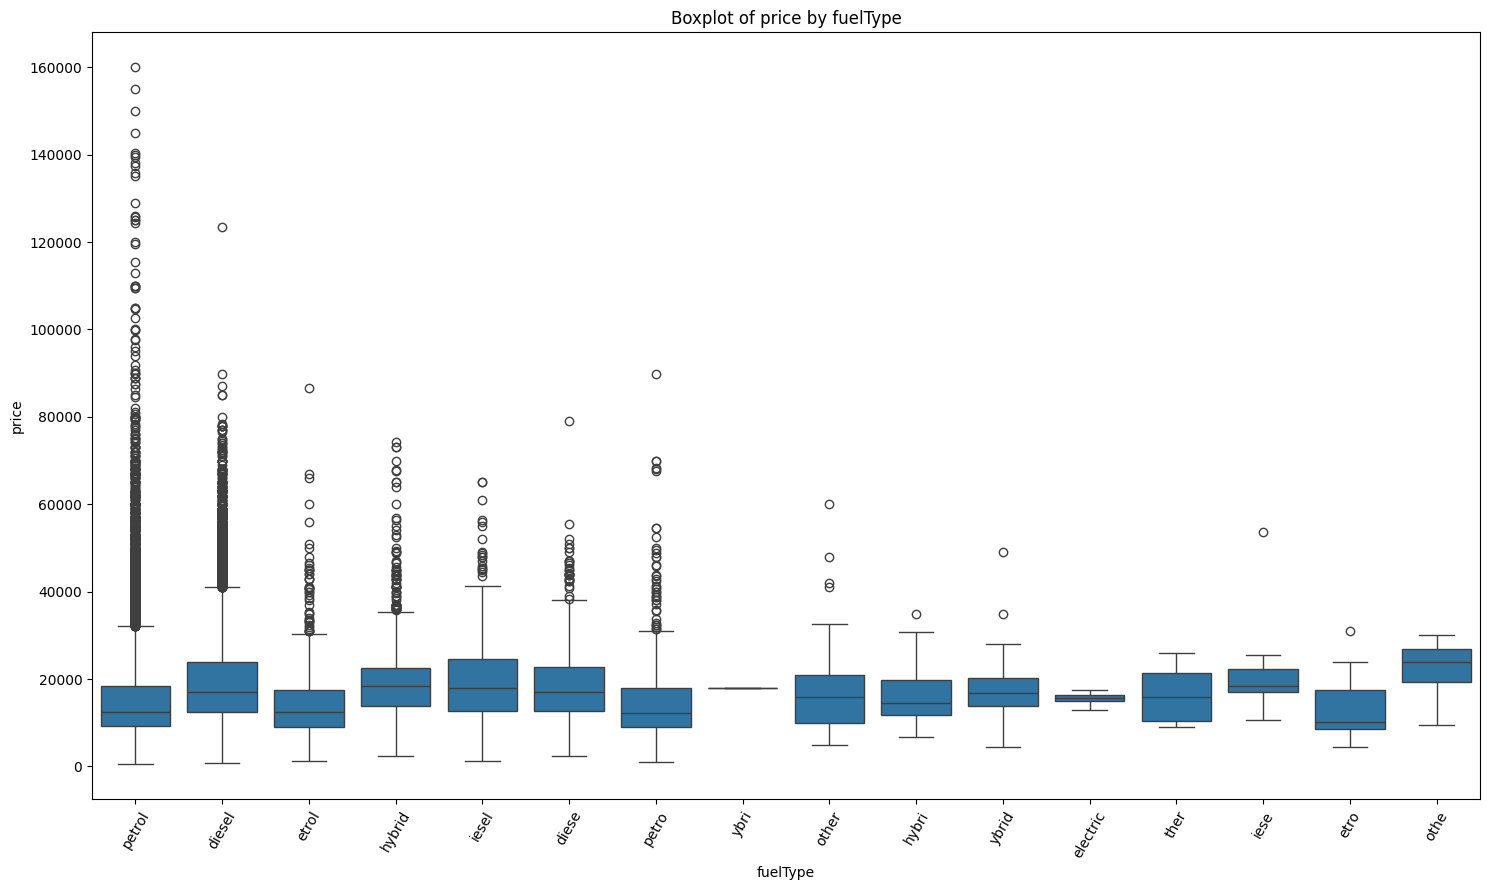

In [17]:
for col in ['Brand', 'transmission', 'fuelType']:
    plt.figure(figsize=(15,9))
    sns.boxplot(data=train_df, x=train_df[col].str.lower(), y='price')
    plt.title(f'Boxplot of price by {col}')
    plt.xticks(rotation=60)
    plt.tight_layout()

With this visualization we intend to verify how our numerical features compare to our target and if there are any visible tendencies when comparing features.
- There is a noticeable trend for models to be pricier if they are newer but these trend seems to only be valid until 2020
- Another trend is for mileage to have an inverse relation to price as a smaller mileage equates to a higher price
- There is a slight trend for bigger engines to be associated with more expensive cars
 

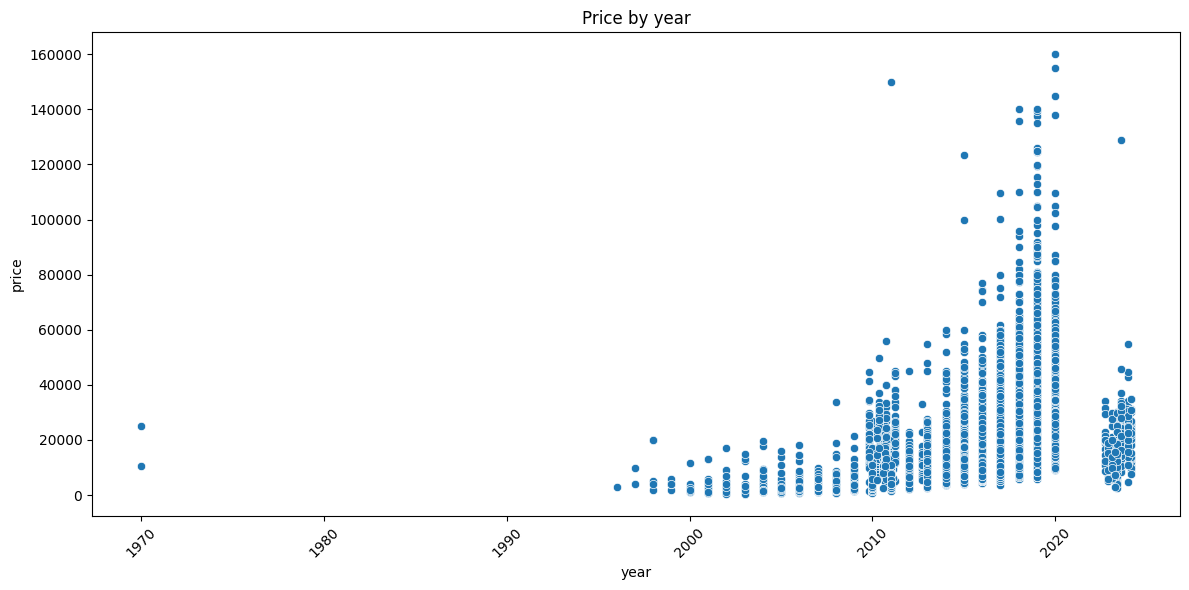

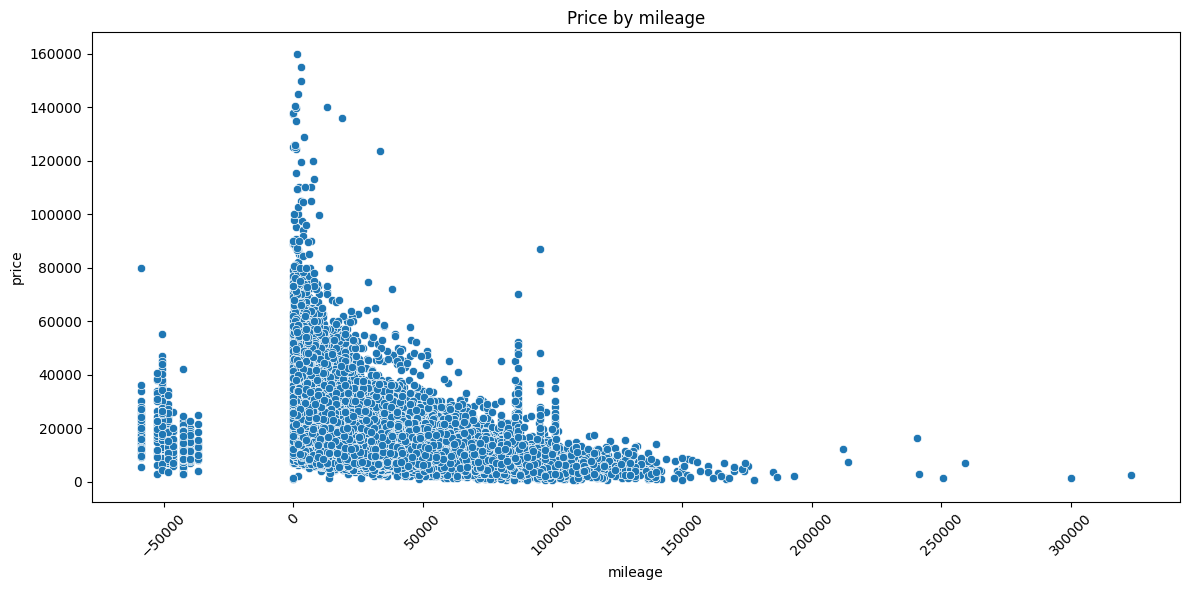

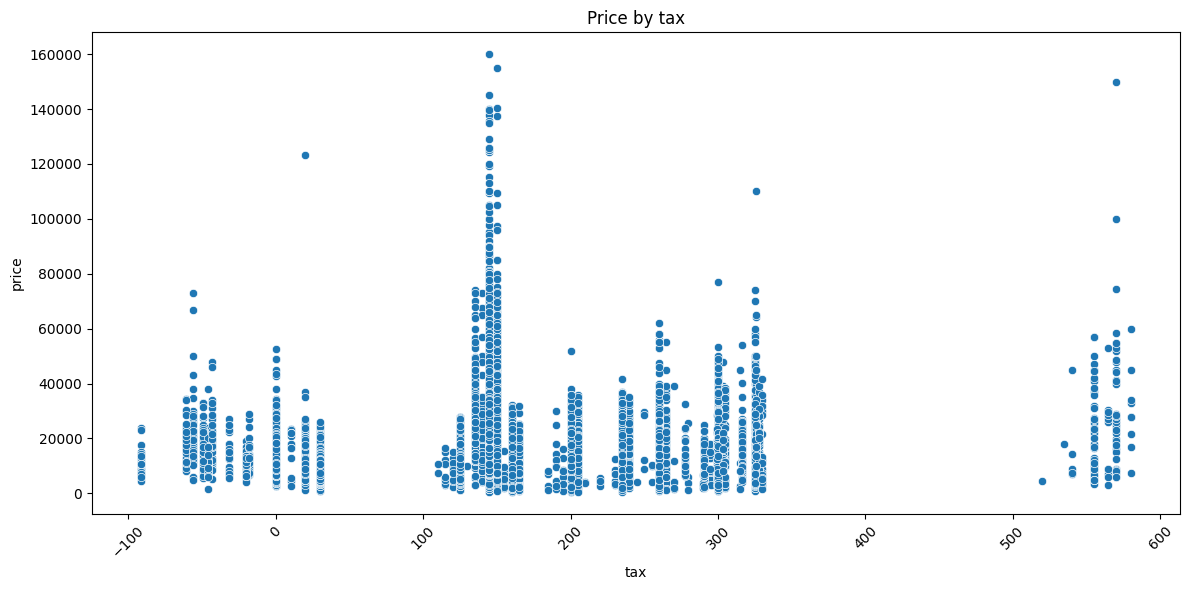

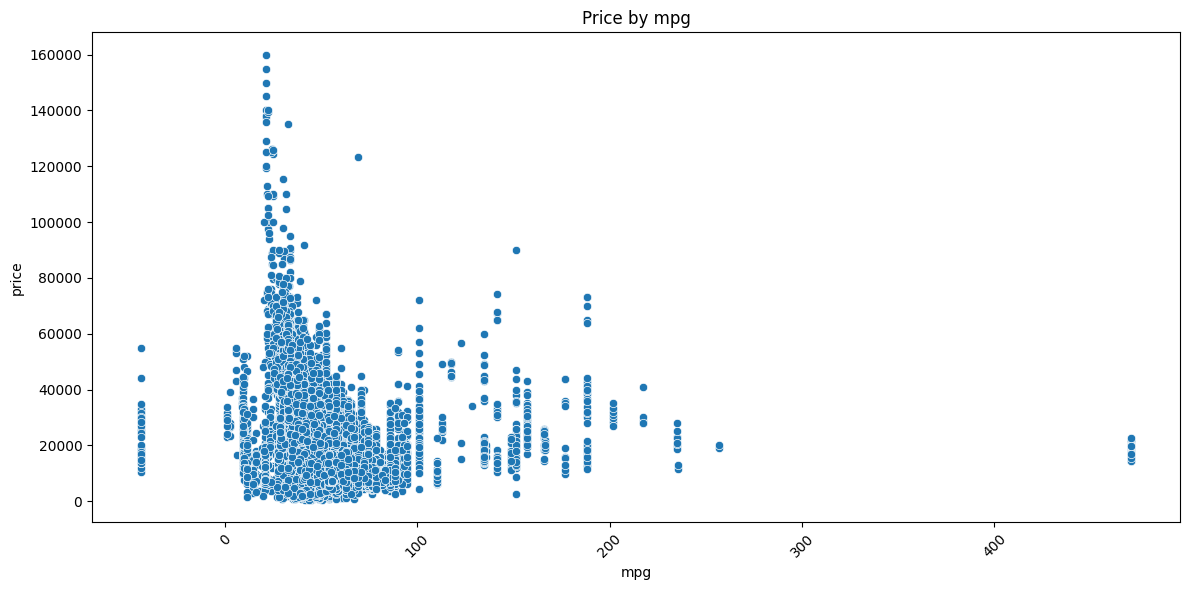

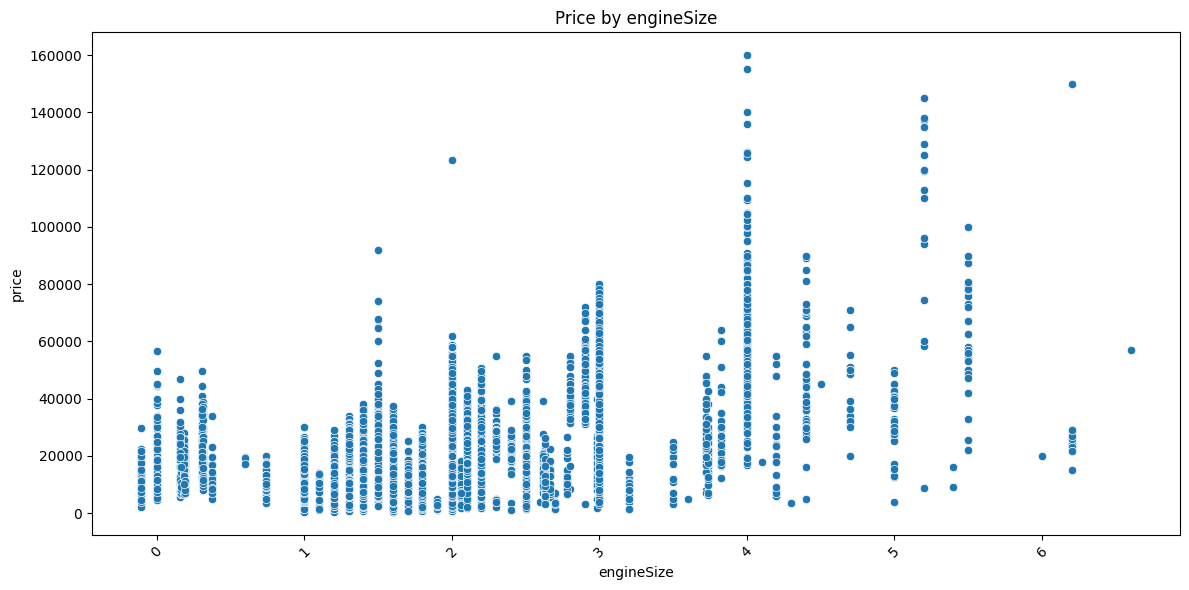

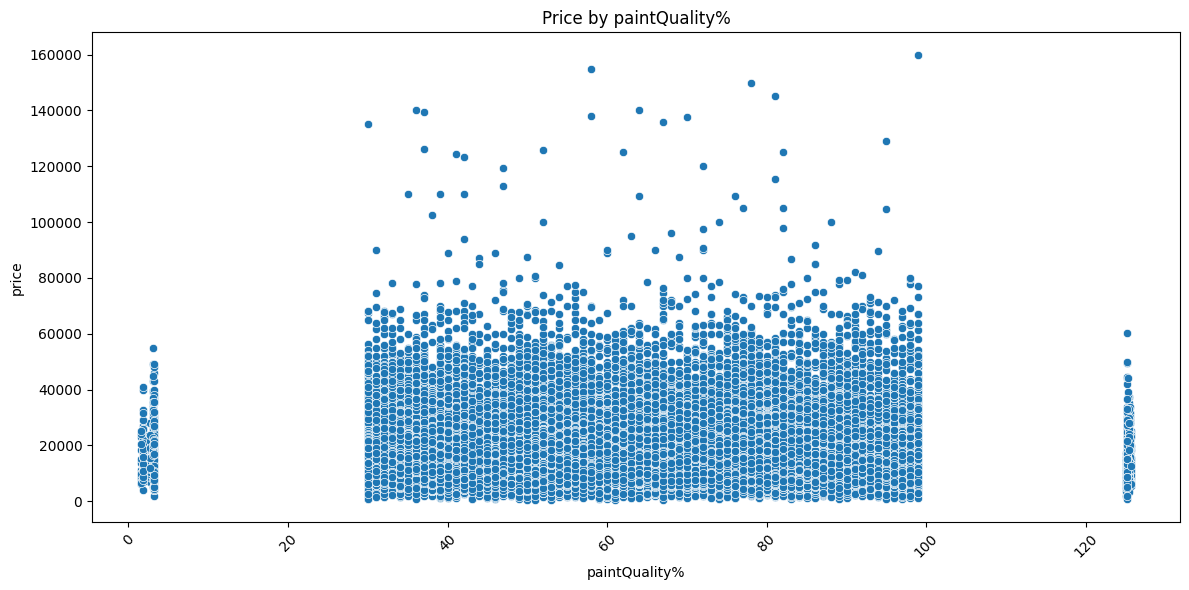

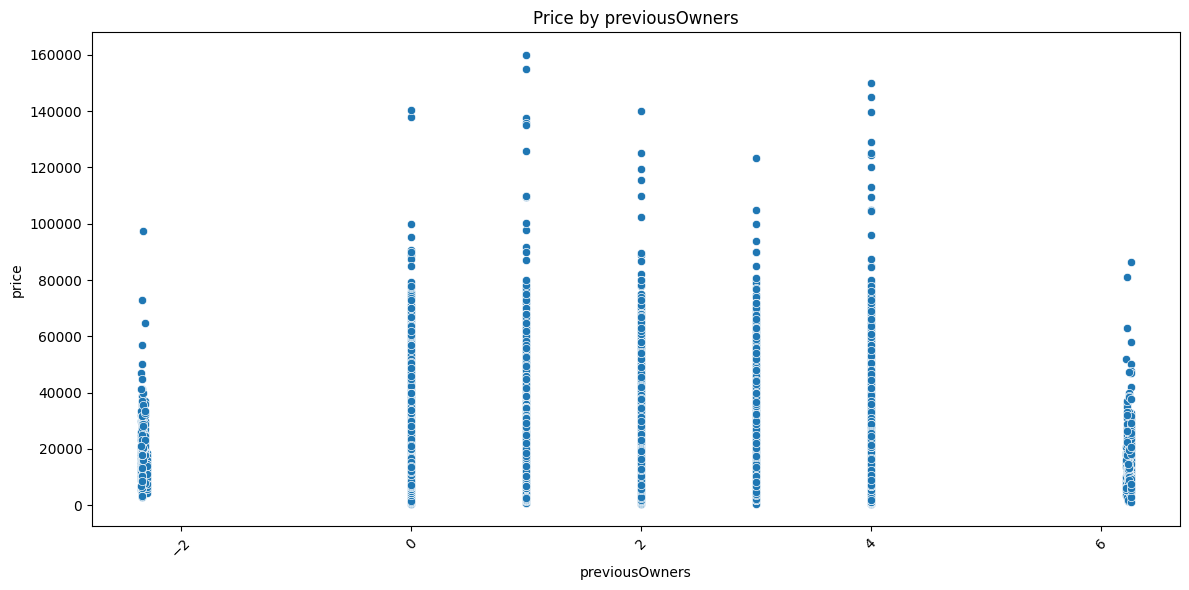

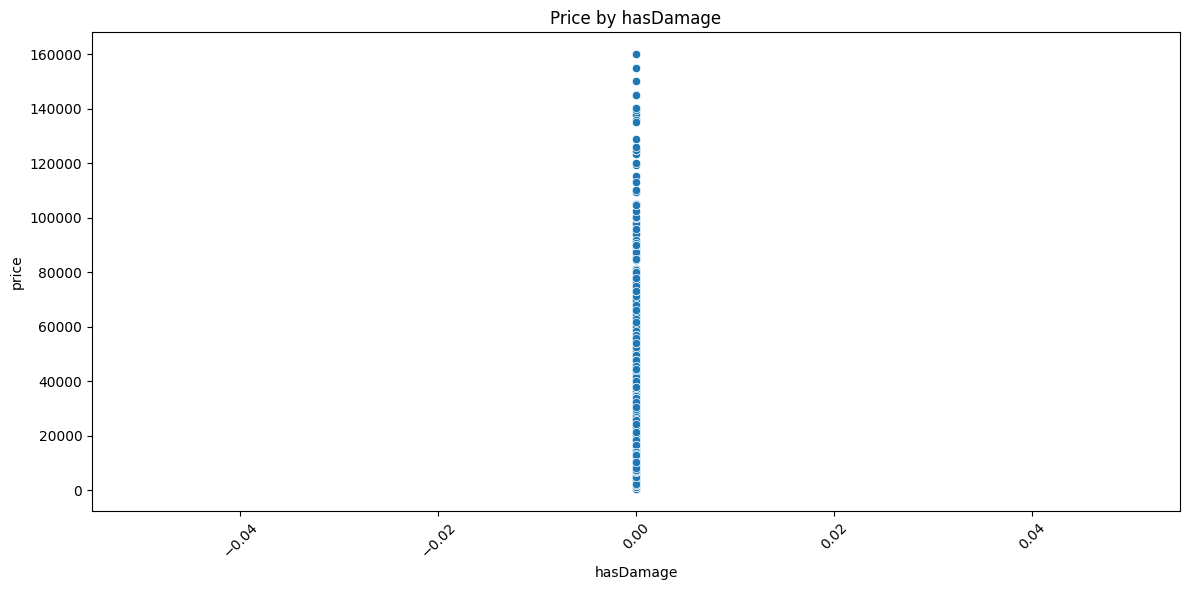

In [18]:
for col in [c for c in numeric_features if c != 'price']:
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=train_df, x=col, y='price')
    plt.title(f'Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

With this plot we analyze the density of the distribution , verifying the spread and the areas where values concentrate. Given the values, we may conclude that mercedes, bmw and audi have large outliers with little representation which might mean that these cars are higher -end models while other like opel have smal values ad

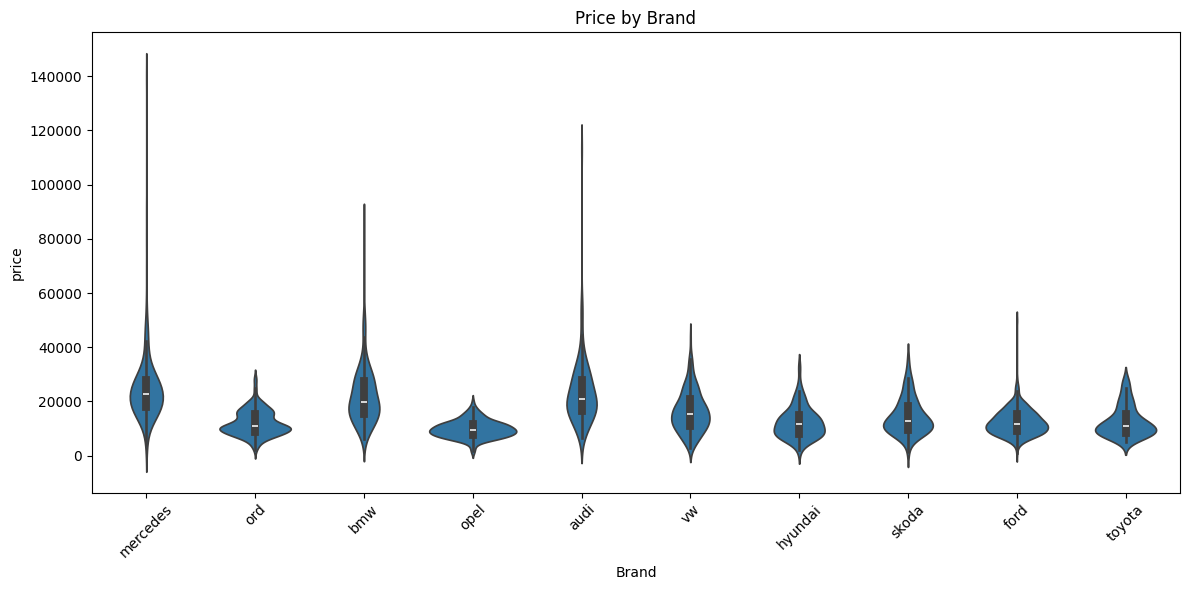

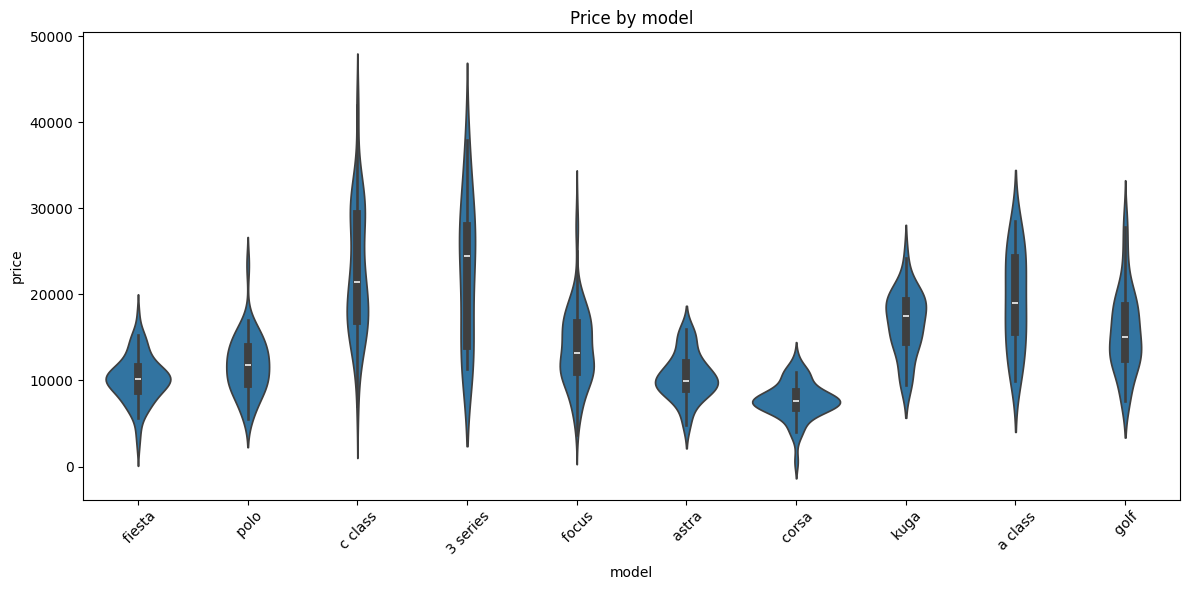

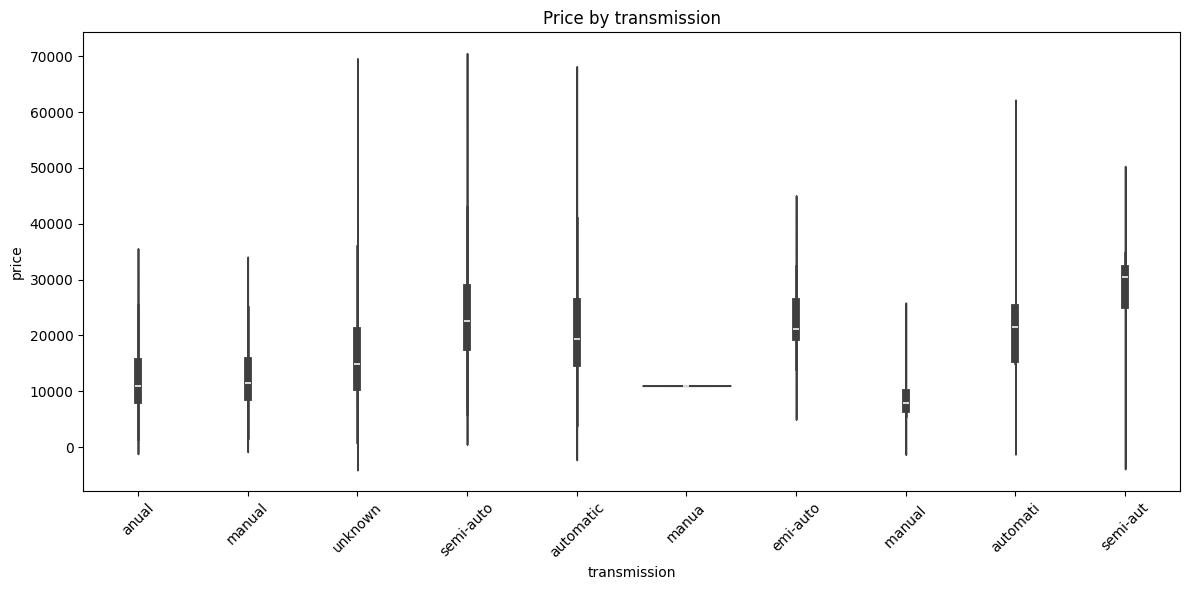

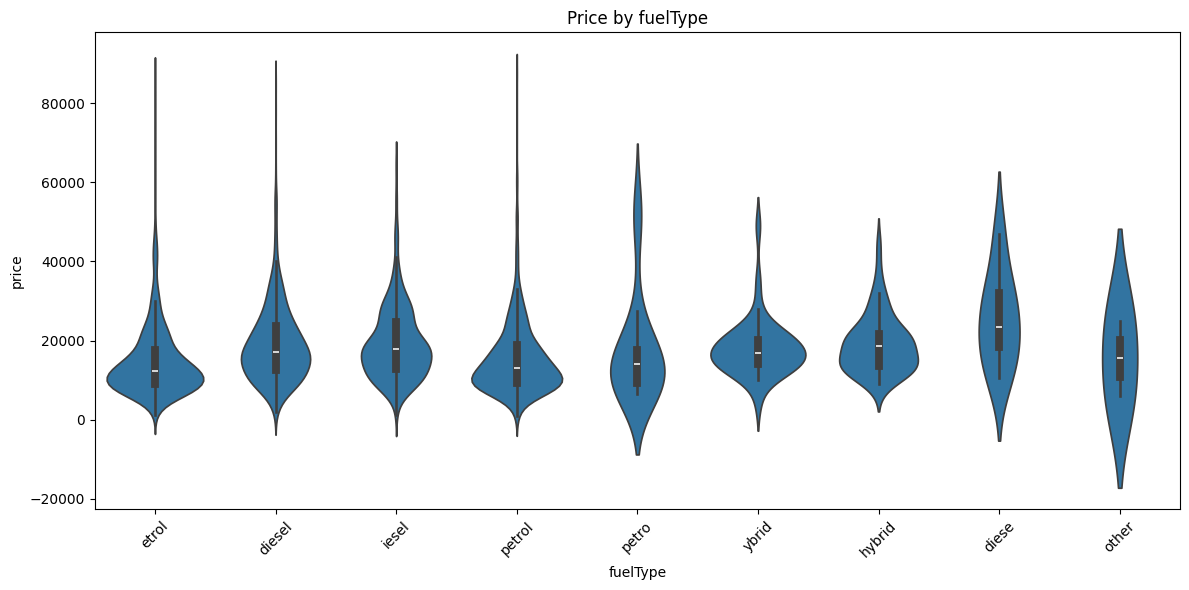

In [19]:
for col in categorical_features:
    top_values = train_df[train_df[col].isin(train_df[col].str.lower().value_counts().head(10).index)]
    plt.figure(figsize=(12,6))
    sns.violinplot(data=top_values, x=top_values[col].str.lower(), y='price')
    plt.title(f'Price by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

When comparing fuel type to mpg, there is a clear difference as hybrid models have considerable mpg. When comparing transmission to mpg, these are mostly balanced with semi-auto having slightly less mpg

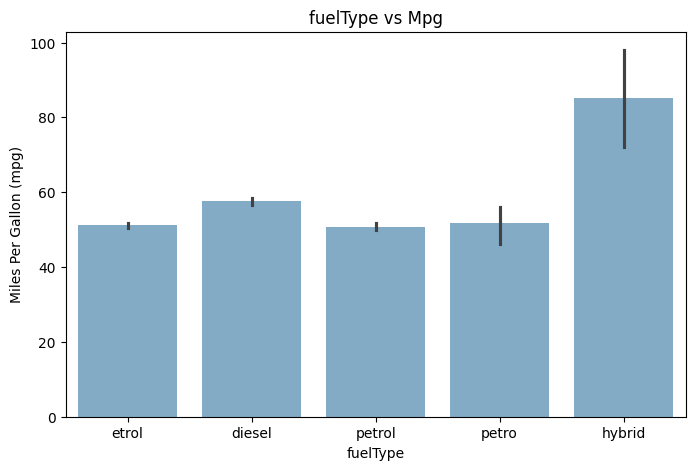

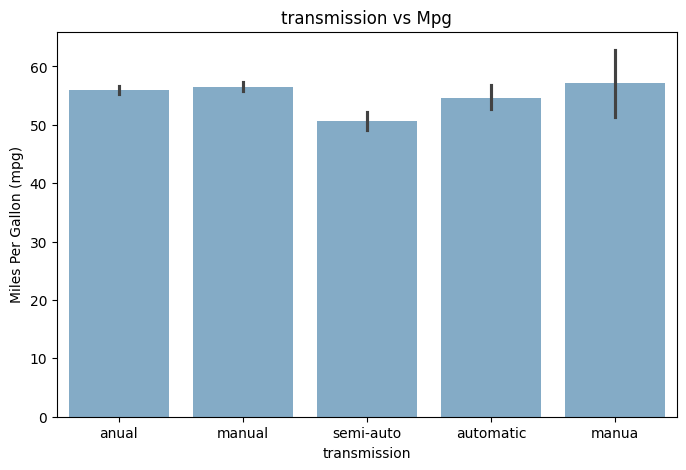

In [20]:
for col in ['fuelType', 'transmission']:
    top_values = train_df[train_df[col].isin(train_df[col].str.lower().value_counts().head(5).index)]

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=top_values, 
        x=col, 
        y='mpg',
        alpha=0.6
    )
    plt.title(f'{col} vs Mpg')
    plt.xlabel(f'{col}')
    plt.ylabel('Miles Per Gallon (mpg)')
    plt.show()

With this plot we tried to check if there was any tendency for bigger engine to yield more mpg but these two features do not demonstrate much of relationship

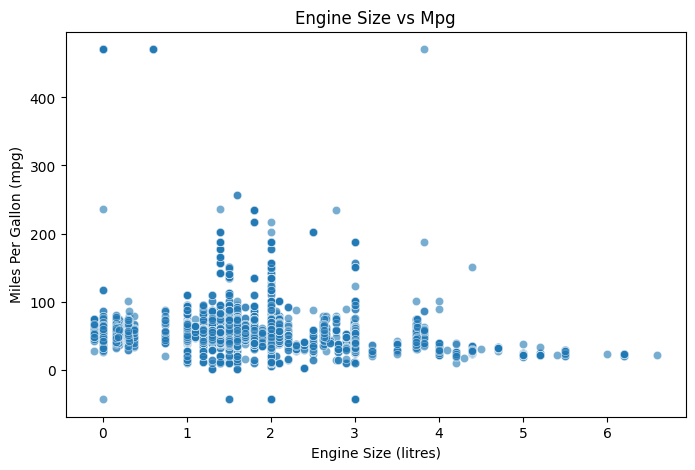

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=train_df, 
    x='engineSize', 
    y='mpg',
    alpha=0.6
)
plt.title('Engine Size vs Mpg')
plt.xlabel('Engine Size (litres)')
plt.ylabel('Miles Per Gallon (mpg)')
plt.show()

With this lot we checked if paint quality might have any kind of association to the number of owners (i.e. cars tending to have less paint quality when associated to more owners). The distribution of paint quality seems to be completely dissociated from the number of owners as the distribution is virtually the same for every case.

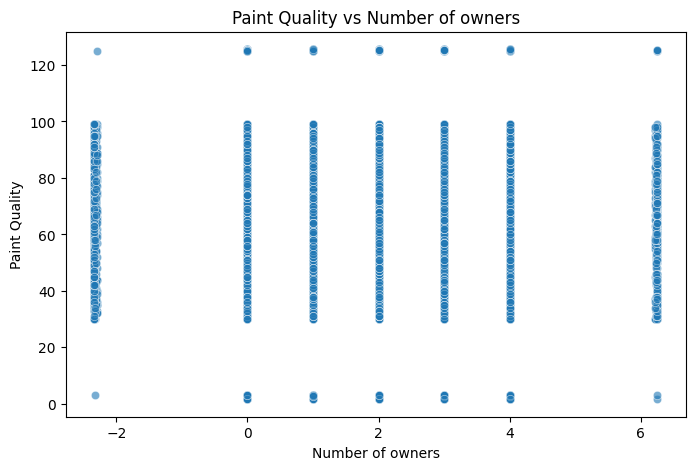

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=train_df, 
    x='previousOwners', 
    y='paintQuality%',
    alpha=0.6
)
plt.title('Paint Quality vs Number of owners')
plt.xlabel('Number of owners')
plt.ylabel('Paint Quality')
plt.show()

In-depth exploration

In [23]:
train_df['Brand'].value_counts()

Brand
Ford        14808
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
            ...  
OYOTA           2
SKOD            1
TOYOT           1
skod            1
toyot           1
Name: count, Length: 72, dtype: int64

In [24]:
train_df['model'].value_counts()

model
 Focus        6353
 C Class      4886
 Fiesta       4130
 Golf         3081
 Corsa        2182
              ... 
M5               1
 gls class       1
Mokka            1
 6 Serie         1
 JETTA           1
Name: count, Length: 735, dtype: int64

In [25]:
train_df['engineSize'].value_counts()

engineSize
 2.000000    20105
 1.000000    13615
 1.500000     9156
 1.400000     7432
 1.600000     6381
 1.200000     4750
 3.000000     3806
 2.100000     3624
 1.800000     1192
 1.300000      920
 1.700000      618
 1.100000      385
 2.500000      312
 4.000000      295
 2.200000      295
 2.300000      181
 0.000000      180
 2.900000      116
-0.103493       84
 2.631200       80
 0.307074       65
 3.723712       63
 2.985793       52
 0.186425       52
 0.739534       52
 2.064119       51
 4.400000       46
 2.400000       43
 0.154529       39
 3.739235       38
 5.000000       38
 0.313407       35
 5.500000       31
 3.822758       27
 2.800000       26
 2.619641       25
 0.162866       24
 1.900000       23
 0.191462       21
 4.200000       20
 2.781776       19
 3.200000       19
 6.200000       19
 4.700000       18
 0.371127       18
 2.663113       17
 5.200000       17
 3.500000       12
 2.700000        7
 0.600000        4
 5.400000        2
 6.600000        1
 

In [26]:
train_df['transmission'].value_counts()

transmission
Manual       38050
Semi-Auto    15545
Automatic    14003
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Semi-Aut       332
emi-Auto       325
semi-auto      324
utomatic       313
SEMI-AUTO      309
Automati       304
AUTOMATIC      289
automatic      282
unknow          18
Manual          16
UNKNOWN         14
ANUAL           13
nknown          13
anua            12
SEMI-AUT        11
MANUA           11
emi-auto        10
 MANUAL          9
EMI-AUTO         7
 Manual          7
automati         6
utomati          6
 manual          6
AUTOMATI         6
emi-Aut          5
Other            5
semi-aut         4
manua            2
UTOMATIC         2
manual           1
nknow            1
Name: count, dtype: int64

In [27]:
train_df['fuelType'].value_counts()

fuelType
Petrol      37995
Diesel      28474
Hybrid       2043
PETROL        795
etrol         794
Petro         785
petrol        746
iesel         603
diesel        599
Diese         582
DIESEL        582
Other         150
HYBRID         50
hybrid         46
Hybri          43
ybrid          37
petro          18
etro           17
ETROL          16
IESEL          16
PETRO          14
DIESE          10
iese           10
diese           8
Othe            6
ther            6
Electric        4
YBRID           3
OTHER           3
other           2
HYBRI           2
ybri            1
ETRO            1
IESE            1
Name: count, dtype: int64

In [28]:
train_df['previousOwners'].value_counts()

previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64

In [29]:
train_df.query('engineSize == 0.0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
21935,Ford,KA,2018.0,8444,Manual,17000.0,Petrol,145.0,57.7,0.0,51.0,0.0,0.0
9518,BMW,2 Series,2015.0,14700,Automatic,32882.0,Diesel,125.0,60.1,0.0,55.0,0.0,0.0
32528,Hyundai,Tucson,2016.0,13800,Manual,27311.0,Diesel,30.0,61.7,0.0,73.0,1.0,0.0
33804,Hyundai,Tucson,2019.0,15000,Manual,22397.0,Petrol,150.0,34.9,0.0,54.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26630,Ford,Fiesta,2018.0,11463,NaN,18000.0,Petro,145.0,65.7,0.0,82.0,0.0,0.0
20128,Ford,Focus,2018.0,18389,Manual,19000.0,Petrol,NaN,NaN,0.0,48.0,2.0,0.0
47605,Skoda,Fabia,2018.0,11500,Manual,10720.0,Petrol,150.0,64.2,0.0,84.0,4.0,0.0


In [30]:
train_df.query('engineSize == 0').groupby(['Brand', 'model'])['engineSize'].count()

Brand   model 
Audi    A1        1
        A3        3
        A4        1
        A5        1
        Q2        3
                 ..
VW      T-Roc     2
        Tiguan    2
bmw     i3        2
hyunda  I10       1
ord     Mondeo    1
Name: engineSize, Length: 62, dtype: int64

In [31]:
train_df.query('engineSize >= 6')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
38980,Mercedes,C Class,2013.0,23000,Semi-Auto,43442.000000,Petrol,NaN,NaN,6.2,76.0,0.0,0.0
46372,Mercedes,C Class,2013.0,22995,Semi-Auto,49964.000000,Petrol,NaN,23.0,6.2,78.0,3.0,0.0
9197,BMW,7 Series,2017.0,57000,Automatic,11297.000000,Petrol,145.000000,22.1,6.6,68.0,1.0,0.0
42286,Mercedes,C Class,2014.0,26998,Semi-Auto,24175.000000,Petrol,NaN,NaN,6.2,93.0,2.0,0.0
39900,Mercedes,C Class,2014.0,28990,Semi-Auto,19562.000000,Petrol,-56.193202,NaN,6.2,83.0,0.0,0.0
39852,ercedes,S Class,2010.0,26990,Automatic,38000.000000,Petrol,570.000000,19.5,6.2,76.0,4.0,0.0
35612,Mercedes,C Class,2013.0,23990,Automatic,NaN,Petrol,570.000000,23.5,6.2,44.0,2.0,0.0
36196,Mercedes,C Clas,2014.0,25885,Semi-Auto,86705.854885,Petrol,NaN,NaN,6.2,31.0,0.0,0.0
35538,NaN,C Class,NaN,22995,Semi-Auto,49964.000000,Petrol,326.028233,NaN,6.2,58.0,3.0,0.0


In [32]:
train_df.query('year < 2010')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35220,Mercedes,SLK,2003.000000,3650,Automatic,58500.0,Petrol,325.0,30.0,2.3,45.0,4.0,0.0
56599,Opel,Astra,2009.000000,1950,Automatic,112000.0,Petrol,305.0,36.2,1.8,71.0,2.0,0.0
34317,Hyundai,Getz,2007.000000,1995,unknown,57000.0,Petrol,125.0,51.4,1.1,45.0,4.0,NaN
44251,Mercedes,C Class,2005.000000,2495,Automatic,110461.0,Diesel,NaN,NaN,2.1,57.0,1.0,0.0
56163,Opel,Corsa,2004.000000,2444,Manual,NaN,Petrol,NaN,53.3,1.0,69.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12161,BMW,2 Series,2009.816757,13700,Automatic,52541.0,Diesel,125.0,57.6,2.0,46.0,0.0,0.0
1150,Audi,RS4,2006.000000,17999,anual,66000.0,Petrol,535.0,20.3,4.2,84.0,1.0,0.0
18141,Ford,C-MAX,2008.000000,1999,Manual,97000.0,Petrol,235.0,39.8,1.8,98.0,4.0,0.0


In [33]:
train_df.query('mileage <= 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,Tiguan,2020.0,25000,Manual,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,C Class,2019.0,25780,Semi-Auto,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,Golf,2018.0,14995,Manual,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3 Series,2019.0,23498,Semi-Auto,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,2017.0,8895,Manual,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,NaN,2018.0,8514,Manual,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLE Class,2020.0,54995,Automatic,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,2015.0,17900,Automati,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


In [34]:
train_df.query('mileage > 50000')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
14704,BMW,3 Series,2014.0,8199,anual,101153.348285,Diesel,30.0,65.7,2.0,74.0,0.0,0.0
50783,Skoda,Octavia,2017.0,7500,Manual,116750.000000,Diesel,145.0,68.9,1.6,59.0,4.0,0.0
34015,Hyundai,I30,2016.0,7500,manual,51236.000000,Diesel,20.0,72.4,1.6,94.0,4.0,0.0
68197,w,Golf,2013.0,12299,Automatic,64739.000000,Petrol,160.0,44.1,2.0,47.0,4.0,0.0
55065,Toyota,C-HR,2017.0,15490,Automatic,59000.000000,Hybrid,0.0,74.3,1.8,95.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45758,Mercedes,CL Class,2015.0,17491,Semi-Auto,54943.000000,Diesel,20.0,62.8,2.1,74.0,3.0,0.0
66803,VW,Polo,2017.0,9895,Manual,50899.000000,Petrol,150.0,60.1,1.2,65.0,3.0,0.0
35773,Mercedes,C Class,2015.0,13790,NaN,54000.000000,Petrol,125.0,52.3,2.0,48.0,1.0,0.0


In [35]:
train_df.query('tax == 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
55065,Toyota,C-HR,2017.0,15490,Automatic,59000.0,Hybrid,0.0,74.3,1.8,95.0,2.0,0.0
64396,Opel,Astra,2015.0,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
54783,Toyota,Yaris,2014.0,10490,Automatic,34528.0,Hybrid,0.0,80.7,1.5,79.0,1.0,0.0
47148,Skoda,Rapid,2016.0,7991,Manual,33395.0,iesel,0.0,67.3,1.6,NaN,3.0,0.0
19051,Ford,Fiesta,2013.0,6500,Manual,43181.0,Petrol,0.0,65.7,1.0,88.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54268,Toyota,Aygo,2017.0,6620,Manual,10266.0,Petrol,0.0,69.0,1.0,51.0,0.0,0.0
52992,Toyota,Aygo,2016.0,8550,Manual,20680.0,Petrol,0.0,69.0,1.0,66.0,2.0,0.0
30535,For,Fiesta,2016.0,8990,Manual,46000.0,NaN,0.0,65.7,1.0,88.0,2.0,0.0


In [36]:
train_df.query('tax < 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,C Clas,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6000,59.0,NaN,0.0
46204,Mercedes,C Class,2019.0,66699,Semi-Auto,630.0,Petrol,-56.193202,28.5,4.0000,32.0,2.0,0.0
24750,Ford,Fiesta,2019.0,17000,Manual,796.0,Petrol,-45.780610,58.9,1.0000,80.0,4.0,0.0
20350,Ford,Focus,2015.0,7260,Manual,60661.0,Petrol,-45.780610,60.1,1.0000,NaN,2.0,0.0
64978,Opel,Astra,2016.0,9595,Automatic,30765.0,Petrol,-20.241079,50.4,1.4000,30.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11302,BMW,4 Series,2018.0,21470,Automatic,40553.0,Petrol,-43.242082,41.5,3.0000,44.0,3.0,0.0
44238,Mercedes,SLK,2001.0,4990,Automatic,64476.0,Petrol,-56.193202,27.2,3.2000,47.0,3.0,0.0
20309,Ford,Fiesta,2013.0,6000,Manual,48133.0,Petrol,-45.780610,54.3,2.6312,40.0,4.0,0.0


In [37]:
train_df.query('mpg < 0')

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
13396,BMW,X1,2019.0,25480,Semi-Auto,5163.000000,Petrol,145.000000,-43.421768,2.0,86.0,1.0,0.0
14934,BMW,3 Series,2019.0,29500,Automatic,3185.000000,Petrol,145.000000,-43.421768,2.0,97.0,3.0,0.0
14127,BMW,2 Series,2020.0,32450,Semi-Auto,1118.000000,Diesel,145.000000,-43.421768,2.0,37.0,1.0,0.0
14420,BMW,2 Series,2015.0,17799,Automatic,38902.000000,Petrol,260.000000,-43.421768,3.0,33.0,4.0,0.0
12400,BMW,X5,2016.0,26995,Automatic,46126.000000,Diesel,200.000000,-43.421768,3.0,77.0,2.0,0.0
14603,BMW,2 Series,2015.0,17541,Semi-Auto,26035.000000,Petrol,165.000000,-43.421768,2.0,75.0,3.0,0.0
11181,BMW,1 Series,2019.0,19298,Semi-Auto,10040.000000,Diesel,145.000000,-43.421768,2.0,70.0,3.0,0.0
7781,BMW,3 Series,2017.0,14800,Manual,29968.000000,DIESEL,30.000000,-43.421768,2.0,52.0,1.0,0.0
9202,BMW,X1,2016.0,17000,Automatic,46968.000000,Diesel,125.000000,-43.421768,2.0,82.0,0.0,0.0


In [38]:
train_df.query('mpg <= 30').groupby(['fuelType'])['mpg'].count()

fuelType
DIESE       1
DIESEL      4
Diese       2
Diesel    214
HYBRID      1
Hybrid     27
IESEL       1
Other       1
PETROL     16
Petro      14
Petrol    724
diesel      4
etrol      16
hybrid      1
iesel       3
petro       1
petrol     16
Name: mpg, dtype: int64

In [39]:
train_df.query('mpg >= 200').groupby(['fuelType'])['mpg'].count()

fuelType
Electric     2
Hybri        1
Hybrid      39
Other        6
hybrid       1
ybrid        1
Name: mpg, dtype: int64

In [40]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('m')]


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
10436,BMW,M,2017.0,36595,Semi-Auto,10950.0,Petrol,145.0,34.0,3.0,57.0,4.0,0.0
9651,BMW,M,2019.0,58991,SEMI-AUTO,16529.0,Petrol,145.0,26.9,4.4,75.0,2.0,0.0
7816,BMW,M,2019.0,44898,Semi-Auto,8124.0,Petrol,145.0,34.0,3.0,34.0,3.0,0.0


In [41]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('x')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
8777,BMW,X,2019.0,23950,Manual,4242.0,Petrol,150.0,42.8,1.5,38.00000,2.0,0.0
10562,BMW,X,2018.0,36498,Semi-Auto,4015.0,Diesel,145.0,47.1,3.0,33.00000,3.0,0.0
13352,BMW,X,2015.0,20250,NaN,54116.0,Diesel,205.0,47.9,3.0,85.00000,0.0,0.0
15010,BMW,X,2019.0,25450,Semi-Auto,5652.0,Diesel,145.0,47.9,2.0,56.00000,3.0,0.0
14615,BMW,x,2016.0,19295,Semi-Auto,13049.0,Diesel,125.0,57.6,2.0,36.00000,4.0,0.0
11265,BMW,X,2019.0,54991,Automatic,15.0,Diesel,145.0,37.7,3.0,62.00000,2.0,0.0
12004,BMW,X,2016.0,21950,Semi-Auto,45142.0,Diesel,200.0,47.9,3.0,82.00000,3.0,0.0
10403,bmw,X,2017.0,20990,Semi-Auto,25013.0,Diesel,145.0,57.6,2.0,56.00000,2.0,0.0
14098,NaN,X,2014.0,11000,Automatic,37905.0,Diese,165.0,52.3,2.0,87.00000,0.0,0.0


In [42]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('i')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
14512,BMW,i,2017.0,19000,utomatic,23983.0,Hybrid,0.0,470.8,0.0,95.0,4.0,0.0


In [43]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('z')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
8851,BMW,Z,2016.0,17732,Semi-Auto,16761.0,Petrol,200.0,41.5,2.0,94.0,4.0,0.0
13403,BMW,Z,2014.0,13200,Manual,37957.0,Petrol,200.0,41.5,2.0,61.0,1.0,0.0


In [44]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('a')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
2592,AUDI,A,2013.0,11999,Semi-Auto,53364.0,Diesel,125.0,58.9,2.0,91.0,2.0,0.0
4810,Audi,A,2019.0,32750,Automatic,8305.0,Diesel,145.0,39.8,3.0,63.0,0.0,0.0
1424,Audi,A,2018.0,25990,Semi-Auto,29035.0,NaN,150.0,43.5,2.0,74.0,4.0,0.0
5537,Audi,A,2013.0,15900,Semi-Auto,29323.0,Petrol,160.0,39.2,2.0,42.0,2.0,0.0
1139,Audi,A,2019.0,32990,Automatic,5000.0,Diesel,145.0,47.1,2.0,31.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,Audi,A,2015.0,9999,Manual,72952.0,Diesel,20.0,68.9,2.0,89.0,4.0,0.0
5355,Audi,A,2019.0,20495,Semi-Auto,4781.0,Petrol,150.0,40.9,2.0,86.0,4.0,0.0
2023,Audi,A,2016.0,14850,Manual,49000.0,Diesel,30.0,64.2,2.0,54.0,2.0,0.0


In [45]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('q')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
701,Audi,Q,2019.000000,20999,Manual,5000.0,Petrol,145.0,47.1,1.0,36.0,1.000000,0.0
4859,Audi,Q,2020.000000,31990,Semi-Auto,2166.0,Diesel,145.0,47.1,2.0,93.0,1.000000,0.0
4812,Audi,Q,2017.000000,18771,Manual,15888.0,Petro,150.0,52.3,1.4,99.0,2.000000,0.0
4724,Audi,Q,2017.000000,16295,Automatic,85780.0,Diesel,200.0,47.9,2.0,72.0,3.000000,0.0
532,Audi,Q,2020.000000,40990,Semi-Auto,5000.0,Petrol,145.0,32.1,2.0,37.0,1.000000,0.0
1866,Audi,Q,2023.605276,10950,Manual,65542.0,Diesel,145.0,54.3,2.0,80.0,6.248251,0.0
926,Audi,Q,2019.000000,29665,Manual,5151.0,petrol,NaN,39.2,1.5,35.0,3.000000,NaN
1743,Audi,Q,2017.000000,19400,Semi-Auto,16235.0,Petrol,145.0,54.3,1.4,63.0,0.000000,0.0
2949,Audi,Q,2016.000000,17990,Manual,21421.0,Petrol,145.0,49.6,1.4,66.0,4.000000,0.0


In [46]:
train_df.loc[train_df['model'].astype(str).str.strip().str.lower().eq('rs')]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
687,Audi,RS,2019.0,59995,Semi-Auto,5089.0,Petrol,145.0,30.1,2.9,87.0,1.0,0.0
4383,Audi,RS,2014.0,23491,Automatic,61892.0,Petrol,555.0,26.4,4.2,99.0,1.0,0.0


In [47]:
missing_brand = train_df[train_df['Brand'].isna() & train_df['model'].notna()]
missing_brand['model'].value_counts()

model
 Focus            139
 C Class           87
 Fiesta            69
 Golf              63
 Polo              42
                 ... 
 TOUAREG            1
 Zafira Tourer      1
 A8                 1
 Grand C-MA         1
Touareg             1
Name: count, Length: 206, dtype: int64

# Data Pre-processing

### Data Split

In [48]:
x = train_df.drop(columns=['price'])
y = train_df['price']

In [49]:
x_test = test_df.copy()

In [50]:
X_train, X_val, y_train, y_val = train_test_split(x,y, test_size = 0.2, 
                                                  random_state = 0, 
                                                  shuffle = True)

### Numerical Variables

We will log transform price to compress values making them closer to a normal distribution, therefore preventing overfitting to high values.

In [51]:
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)

hasDamage will be dropped due to all rows registering 0

In [52]:
X_train.drop(columns=['hasDamage'], inplace=True)
x_test.drop(columns=['hasDamage'], inplace=True)
numeric_features.remove('hasDamage')

Some column have negative values that couldn't be logically explain (ex: a car couldn't have negative mileage, the minimum posible would be a brand new car with 0 miles.) We decided to maintain the absolute value, treating the referred negative as typo.

In [53]:
def negative_values(df, column):
   df[column] = np.where(df[column] < 0, -df[column], df[column])

In [54]:
negative_values(X_train, 'mileage')
negative_values(X_train, 'tax')
negative_values(X_train, 'mpg')
negative_values(X_train, 'engineSize')
negative_values(X_train, 'previousOwners')

In [55]:
negative_values(X_val, 'mileage')
negative_values(X_val, 'tax')
negative_values(X_val, 'mpg')
negative_values(X_val, 'engineSize')
negative_values(X_val, 'previousOwners')

In [56]:
negative_values(x_test, 'mileage')
negative_values(x_test, 'tax')
negative_values(x_test, 'mpg')
negative_values(x_test, 'engineSize')
negative_values(x_test, 'previousOwners')

Cap the percentages at 100% as having paint quality with values above 100% would be non-sensical because 100% means that the paint is in perfect conditions

In [57]:
def percentage_cap(df, column):
    df[column] = np.where(df[column] > 100, 100, df[column])

In [58]:
percentage_cap(X_train, 'paintQuality%')
percentage_cap(X_val, 'paintQuality%')
percentage_cap(x_test, 'paintQuality%')

Reduce the number of decimals to 2 in floats

In [59]:
float_cols = train_df.select_dtypes(include='float')
train_df[float_cols.columns] = float_cols.round(2)

Year and Previous Owners are categories that should be integers but are currently float. Giving that there's NA's to be treated later we will identify all valid cases and switch then to integer

In [60]:
def float_to_int(df, column):
    mask = df[column].notna()               # identify non-missing values
    df[column] = df[column].copy()         
    df.loc[mask, column] = np.floor(df.loc[mask, column]).astype(int)
    return df

In [61]:
float_to_int(X_train, 'year')
float_to_int(X_val, 'year')
float_to_int(x_test, 'year')

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,2022.0,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0
106581,VW,Tiguan,2017.0,Semi-Auto,48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0
80886,BMW,2 Series,2016.0,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0
100174,Opel,Grandland X,2019.0,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0
81376,BMW,1 Series,2019.0,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017.0,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1.0
81363,BMW,X2,2020.0,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3.0
76833,Audi,Q5,2019.0,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4.0


In [62]:
float_to_int(X_train, 'previousOwners')
float_to_int(X_val, 'previousOwners')
float_to_int(x_test, 'previousOwners')

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners
carID,,,,,,,,,,,
89856,Hyundai,I30,2022.0,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0
106581,VW,Tiguan,2017.0,Semi-Auto,48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0
80886,BMW,2 Series,2016.0,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0
100174,Opel,Grandland X,2019.0,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0
81376,BMW,1 Series,2019.0,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
105775,VW,Tiguan,2017.0,Manual,27575.000000,Petrol,145.0,46.3,1.4,94.0,1.0
81363,BMW,X2,2020.0,Automatic,1980.000000,Petrol,145.0,34.0,2.0,39.0,3.0
76833,Audi,Q5,2019.0,Semi-Auto,8297.000000,Diesel,145.0,38.2,2.0,88.0,4.0


Outliers

We will cap values regarding the most extreme 1% of the distribution in order to prevent outliers from biasing the predictive models

In [63]:
for col in ["mileage", "tax", "mpg", "engineSize"]:
    lower, upper = X_train[col].quantile([0.01, 0.99])
    
    # Apply clipping using the same limits
    X_train[col] = X_train[col].clip(lower, upper)
    X_val[col] = X_val[col].clip(lower, upper)
    x_test[col] = x_test[col].clip(lower, upper)


### Categorical Variables

The dataset has a large number of different instances for categoricals that consiste mostly of errors and repetitions due to the casing. First we procede to lowercase every instance and then we manually correct the typos identified through value counts.

In [64]:
def preprocess_categoric(df,column):
    df[column] = (
        df[column]
        .str.strip()      # remove leading/trailing spaces
        .str.lower()      # make everything lowercase
    )

In [65]:
preprocess_categoric(X_train,'transmission')
preprocess_categoric(X_val,'transmission')
preprocess_categoric(x_test,'transmission')

In [66]:
preprocess_categoric(X_train,'fuelType')
preprocess_categoric(X_val,'fuelType')
preprocess_categoric(x_test,'fuelType')

In [67]:
preprocess_categoric(X_train,'Brand')
preprocess_categoric(X_val,'Brand')
preprocess_categoric(x_test,'Brand')

In [68]:
preprocess_categoric(X_train,'model')
preprocess_categoric(X_val,'model')
preprocess_categoric(x_test,'model')

After stripping empty space and lowercasing we will manually corrected the typos

In [69]:
def preprocess_transmission(df):
    df['transmission'] = df['transmission'].replace({
        'anual': 'manual', 'manua': 'manual', 'anua': 'manual',
        'utomatic': 'automatic', 'utomati': 'automatic', 'automati': 'automatic',
        'semi-aut': 'semi-auto', 'emi-auto': 'semi-auto', 'emi-aut': 'semi-auto',
        'unknow': 'unknown', 'nknown': 'unknown', 'nknow': 'unknown'
    })

In [70]:
preprocess_transmission(X_train)
preprocess_transmission(X_val)
preprocess_transmission(x_test)

In [71]:
def preprocess_fuelType(df):
    df['fuelType'] = df['fuelType'].replace({
        'petro': 'petrol', 'etrol': 'petrol', 'etro': 'petrol',
        'iesel': 'diesel', 'diese': 'diesel', 'iese': 'diesel',
        'hybri': 'hybrid', 'ybrid': 'hybrid', 'ybri': 'hybrid',
        'othe': 'other', 'ther': 'other',
    })

In [72]:
preprocess_fuelType(X_train)
preprocess_fuelType(X_val)
preprocess_fuelType(x_test)

In [73]:
def preprocess_Brand(df):
    df['Brand'] = df['Brand'].replace({
        'ord': 'ford', 'for': 'ford', 'or': 'ford',
        'ercedes': 'mercedes', 'mercede': 'mercedes', 'ercede': 'mercedes',
        'skod': 'skoda', 'koda': 'skoda', 'kod': 'skoda',
        'oyota': 'toyota', 'toyot': 'toyota',
        'udi': 'audi', 'aud': 'audi', 'ud': 'audi',
        'ope': 'opel', 'pel': 'opel', 'pe': 'opel',
        'yundai': 'hyundai', 'hyunda': 'hyundai', 'yunda': 'hyundai',
        'bm': 'bmw', 'mw': 'bmw', 
        'v': 'vw', 'w': 'vw',
    })

In [74]:
preprocess_Brand(X_train)
preprocess_Brand(X_val)
preprocess_Brand(x_test)

There are 735 models in the dataset but after inspection there are several repeated models due to capitalization and spelling mistakes. After empty space stripping, lowercasing and manual correction a few models remained as the designation was not complete (audi a, audi q, audi rs, bmw x, bmw m, bmw z, bmw i). For all these cases, the letter represents a series of models (ex: there is bmw m1, bmw m2, bmw m3, etc) so we will add the instance to one of the models. For bmw m, bmw z, bmw i there were few instances and a dominant model so we attributed it to the most frequent model. For the other situations, there were several models with considerable representation so we opted to attribute instances based on model distribution. There were a few instances where the brand was missing so we mapped to the brand so that these cases may also work with our imputation. 

In [75]:
def preprocess_model(df):
    df['model'] = df['model'].replace({
        'a clas': 'a class', 'b clas': 'b class', 's clas': 's class', 'c clas': 'c class', 'e clas': 'e class', 'b clas': 'b class', 'glc clas': 'glc class', 'gle clas': 'gle class',
        'ayg': 'aygo', 'fiest': 'fiesta', 'yari': 'yaris', 'coroll': 'corolla', 'k': 'ka', 'galax': 'galaxy', 'scal': 'scala', 'sl': 'sl class',
        'beetl': 'beetle', 'focu': 'focus', 'astr': 'astra', 'octavi': 'octavia', 'meriv': 'meriva', 's-ma': 's-max', 'x-clas': 'x-class',
        'cors': 'corsa', 'pol': 'polo', 'kug': 'kuga', 'tucso': 'tucson', '1 serie': '1 series', '2 serie': '2 series', 'rapi': 'rapid',
        '3 serie': '3 series', '4 serie': '4 series', '5 serie': '5 series', 'gol': 'golf', 'mokk': 'mokka', 'fabi': 'fabia', 't-ro': 't-roc', 
        't-cros': 't-cross', 'mokk': 'mokka', 'insigni': 'insignia', 'fabia': 'fabia', 'glc clas': 'glc class', 'escospor': 'ecosport', 'u': 'up',
        'passa': 'passat', 'zafir': 'zafira', 'santa f': 'santa fe', 'kodia': 'kodiaq', 'b-ma': 'b-max', 'gla clas': 'gla class',
        'ada': 'adam', 'ioni': 'ioniq', 'super': 'superb', 'yeti outdoo': 'yeti outdoor', 'citigo': 'citigo',  'sl clas': 'sl class', 
        'x-cla': 'x-class', 'cls clas': 'cls class', 'kon': 'kona', 'touare': 'touareg', 'scirocc': 'scirocco', 'c-h': 'c-hr', 't': 'tt',
        'cl clas': 'cl class', 'v clas': 'v class', 'gl clas': 'gl class', '7 serie': '7 series', '8 serie': '8 series', '6 serie': '6 series',
        'land cruise': 'land cruiser', 'urban cruise': 'urban cruiser', 'vers': 'verso', 'edg': 'edge', 'm clas': 'm class', 'tourneo custo': 'tourneo custom',
        'yet': 'yeti', 'combo lif': 'combo life', 'caravell': 'caravelle', 'auri': 'auris', 'ecospor': 'ecosport', 'caddy maxi lif': 'caddy maxi life',
        'roomste': 'roomster', 'kami': 'kamiq', 'tiguan allspac': 'tiguan allspace', 'grand tourneo connec': 'grand tourneo connect', 'gls clas': 'gls class',
        'amaro': 'amarok', 'veloste': 'veloster', 'shara': 'sharan', 'arteo': 'arteon', 'zafira toure': 'zafira tourer', 'hilu': 'hilux', 'sl': 'sl class',
        'monde': 'mondeo', 'rav': 'rav4', 'citig': 'citigo', 'toura': 'touran', 'viv': 'vivaro', 'karo': 'karoq', 'c-ma': 'c-max', 'grand c-ma': 'grand c-max',
        'viva': 'vivaro', 'clk': 'clk class', '200': 'c 200', '230': 'c 230', '220': 'c 220', 'slk': 'slk class'
    })

In [76]:
preprocess_model(X_train)
preprocess_model(X_val)
preprocess_model(x_test)

In [77]:
# Define the prefix-to-brand mapping
prefix_to_brand = {
    'a': 'audi', 'q': 'audi', 'x': 'bmw' 
}

# Function to detect prefix and map brand
def infer_brand_from_model(model):
    if isinstance(model, str):
        for prefix, brand in prefix_to_brand.items():
            if model.lower().startswith(prefix):
                return brand
    return None

In [78]:
# Apply mapping to missing brands
X_train['Brand'] = X_train['Brand'].fillna(X_train['model'].apply(infer_brand_from_model))
X_val['Brand']  = X_val['Brand'].fillna(X_val['model'].apply(infer_brand_from_model))
x_test['Brand'] = x_test['Brand'].fillna(x_test['model'].apply(infer_brand_from_model))

In [79]:
X_train['model'] = X_train['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})
X_val['model'] = X_val['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})
x_test['model'] = x_test['model'].replace({'m': 'm4', 'z': 'z4', 'i': 'i3'})

In [80]:
def impute_by_distribution(df, brand, prefix):
    subset = df[(df['Brand'].str.lower() == brand) & (df['model'].str.startswith(prefix))]
    dist = subset[subset['model'] != prefix]['model'].value_counts(normalize=True)
    mask = (df['Brand'].str.lower() == brand) & (df['model'] == prefix)
    df.loc[mask, 'model'] = np.random.choice(dist.index, size=mask.sum(), p=dist.values)

In [81]:
impute_by_distribution(X_train, 'audi', 'a')
impute_by_distribution(X_val, 'audi', 'a')
impute_by_distribution(x_test, 'audi', 'a')
impute_by_distribution(X_train, 'audi', 'q')
impute_by_distribution(X_val, 'audi', 'q')
impute_by_distribution(x_test, 'audi', 'q')
impute_by_distribution(X_train, 'audi', 'rs')
impute_by_distribution(X_val, 'audi', 'rs')
impute_by_distribution(x_test, 'audi', 'rs')
impute_by_distribution(X_train, 'bmw', 'x')
impute_by_distribution(X_val, 'bmw', 'x')
impute_by_distribution(x_test, 'bmw', 'x')

### Feature Engineering

We created the feature age and also mileage per year. Age was created due to being more intuitively interpretable as give us the amount of time the car has been in usage while year only tell us when this car was made. Year will be dropped as this two features share a lot of information, this way we avoid multicolinearity and do not risk biasing the predictors. Mileage per year refers to an analysis on how much usage a model has had since it was made. We believe this feature might have explainable power as in theory model with more usage should have lower prices. This feature also captures information that it is not available in mileage since mileage does not account for how long the car has been in service.

In [82]:
X_train['age'] = 2025 - X_train['year'].astype('Int64')
X_train['mileage per year'] = X_train['mileage'] / X_train['age']
X_train = X_train.drop(columns='year', axis=1)

In [83]:
X_val['age'] = 2025 - X_val['year']
X_val['mileage per year'] = X_val['mileage'] / X_val['age']
X_val = X_val.drop(columns='year', axis=1)

In [84]:
x_test['age'] = 2025 - x_test['year']
x_test['mileage per year'] = x_test['mileage'] / x_test['age']
x_test = x_test.drop(columns='year', axis=1)

In [85]:
numeric_features.remove('price')
numeric_features.remove('year')
numeric_features.extend(['age', 'mileage per year'])

Missing values

When regarding missing values for Brand, we can easily derive it if we have a Model since each Brand as it own lines of Models. However, there are 26 rows in our training set missing both Brand and Model. Out of these there some rows that miss more data. We shall drop these rows due to having too much data missing.

In [86]:
 # Identify rows to drop in the train set
drop_train = X_train['Brand'].isna() & X_train['model'].isna()
rows_to_drop_train = X_train.index[drop_train]

# Drop from both X_train and y_train
X_train = X_train.drop(rows_to_drop_train)
y_train = y_train.drop(rows_to_drop_train)

# Identify rows to drop in VALIDATION
drop_val = X_val['Brand'].isna() & X_val['model'].isna()
rows_to_drop_val = X_val.index[drop_val]

# Drop from both X_val and y_val
X_val = X_val.drop(rows_to_drop_val)
y_val = y_val.drop(rows_to_drop_val)

For the rest we shall map the models to it's brands and fill the missing values according to the mapping

In [87]:
model_to_brand = (
    X_train.dropna(subset=['Brand', 'model']) # consider only non NA's
    .drop_duplicates(subset=['model']) # map a model only once
    .set_index('model')['Brand']
    .to_dict()
)

In [88]:
X_train['Brand'] = X_train['Brand'].fillna(X_train['model'].map(model_to_brand))
X_val['Brand'] = X_val['Brand'].fillna(X_val['model'].map(model_to_brand))
x_test['Brand'] = x_test['Brand'].fillna(x_test['model'].map(model_to_brand))

For model we will group instances by Brand, fuel type use and engine size and attribute the most common model associated. If any of these are missing, we will group by fuel type and brand with a final fallback with Brand.

In [89]:
# Precompute mode mappings from the training data
train_mode_1 = (
    X_train.groupby(['Brand', 'fuelType', 'engineSize'])['model']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_2 = (
    X_train.groupby(['Brand', 'fuelType'])['model']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_3 = (
    X_train.groupby(['Brand'])['model']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [90]:
def impute_model(df):
    key1 = list(zip(df['Brand'], df['fuelType'], df['engineSize']))
    key2 = list(zip(df['Brand'], df['fuelType']))
    key3 = df['Brand']

    df['model'] = (
        df['model']
        .fillna(pd.Series(key1, index=df.index).map(train_mode_1))
        .fillna(pd.Series(key2, index=df.index).map(train_mode_2))
        .fillna(pd.Series(key3, index=df.index).map(train_mode_3))
    )
    return df


In [91]:
X_train = impute_model(X_train)
X_val = impute_model(X_val)
x_test = impute_model(x_test)

Some rows have engine size as 0. For those we will first assign as NA and then attribute a value according to similar models to all missing engine sizes by associating it to similar instances considering model, fuel type and age

In [92]:
train_medians_1 = X_train.groupby(['model', 'fuelType', 'age'])['engineSize'].median()
train_medians_2 = X_train.groupby(['fuelType', 'model'])['engineSize'].median()
train_medians_3 = X_train.groupby(['model'])['engineSize'].median()
train_medians_4 = X_train.groupby(['engineSize'])['engineSize'].median()

In [93]:
def impute_engine_size(df):
    df['engineSize'] = df['engineSize'].replace(0, np.nan)
    key1 = list(zip(df['model'], df['fuelType'], df['age']))
    key2 = list(zip(df['fuelType'], df['model']))
    key3 = df['model']
    key4 = df['engineSize']

    df['engineSize'] = (
        df['engineSize']
        .fillna(pd.Series(key1, index=df.index).map(train_medians_1))
        .fillna(pd.Series(key2, index=df.index).map(train_medians_2))
        .fillna(pd.Series(key3, index=df.index).map(train_medians_3))
        .fillna(pd.Series(key4, index=df.index).map(train_medians_4))
    )
    return df

In [94]:
impute_engine_size(X_train)
impute_engine_size(X_val)
impute_engine_size(x_test)

,Brand,model,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,age,mileage per year
carID,,,,,,,,,,,,
89856,hyundai,i30,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,3.0,10233.333333
106581,vw,tiguan,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,8.0,6023.831959
80886,bmw,2 series,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,9.0,4088.000000
100174,opel,grandland x,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,6.0,922.166667
81376,bmw,1 series,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,6.0,1509.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,8.0,3446.875000
81363,bmw,x2,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,5.0,396.000000
76833,audi,q5,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,6.0,1382.833333


Once again we will use the remaining info about the car to impute missing values to models that are similar.

In [95]:
train_medians_5 = X_train.groupby(['model', 'engineSize'])['age'].median()
train_medians_6 = X_train.groupby(['model'])['age'].median()

In [96]:
def impute_age(df):
    key1 = list(zip(df['model'], df['engineSize']))  
    key2 = df['model']        

    df['age'] = (
        df['age']
        .astype(float)
        .fillna(pd.Series(key1, index=df.index).map(train_medians_5))
        .fillna(pd.Series(key2, index=df.index).map(train_medians_6))
    )
    return df

In [97]:
impute_age(X_train)
impute_age(X_val)
impute_age(x_test)

,Brand,model,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,age,mileage per year
carID,,,,,,,,,,,,
89856,hyundai,i30,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,3.0,10233.333333
106581,vw,tiguan,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,8.0,6023.831959
80886,bmw,2 series,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,9.0,4088.000000
100174,opel,grandland x,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,6.0,922.166667
81376,bmw,1 series,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,6.0,1509.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,8.0,3446.875000
81363,bmw,x2,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,5.0,396.000000
76833,audi,q5,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,6.0,1382.833333


Fuel Type follows the same logic this time using Brand, model and engine size

In [98]:
train_mode_4 = (
    X_train.groupby(['Brand', 'model', 'engineSize'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_5 = (
    X_train.groupby(['model', 'engineSize'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_6 = (
    X_train.groupby(['model'])['fuelType']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [99]:
def impute_fuelType(df):
    key1 = list(zip(df['Brand'], df['model'], df['engineSize']))
    key2 = list(zip(df['model'], df['engineSize'])) 
    key3 = df['model']
    key4 = df['fuelType']                          

    df['fuelType'] = (
        df['fuelType']
        .fillna(pd.Series(key1, index=df.index).map(train_mode_4))
        .fillna(pd.Series(key2, index=df.index).map(train_mode_5))
        .fillna(pd.Series(key3, index=df.index).map(train_mode_6))
        .fillna(df['fuelType'].mode()[0])
    )
    return df

In [100]:
impute_fuelType(X_train)
impute_fuelType(X_val)
impute_fuelType(x_test)

,Brand,model,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,age,mileage per year
carID,,,,,,,,,,,,
89856,hyundai,i30,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,3.0,10233.333333
106581,vw,tiguan,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,8.0,6023.831959
80886,bmw,2 series,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,9.0,4088.000000
100174,opel,grandland x,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,6.0,922.166667
81376,bmw,1 series,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,6.0,1509.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,8.0,3446.875000
81363,bmw,x2,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,5.0,396.000000
76833,audi,q5,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,6.0,1382.833333


Transmission was imputed by combining other characteristics associated to the vehicle with the keys representing the conditions that will be hierarchically used with key2 only being used if key1 doesn't capture all missing values and so on.

In [101]:
train_mode_7 = (
    X_train.groupby(['Brand', 'model', 'fuelType', 'engineSize'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_8 = (
    X_train.groupby(['model', 'fuelType', 'engineSize'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
train_mode_9 = (
    X_train.groupby(['model'])['transmission']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [102]:
def impute_transmission(df):
    key1 = list(zip(df['Brand'], df['model'], df['fuelType'], df['engineSize']))
    key2 = list(zip(df['model'], df['fuelType'], df['engineSize']))
    key3 = df['model']

    df['transmission'] = (
        df['transmission']
        .fillna(pd.Series(key1, index=df.index).map(train_mode_7))
        .fillna(pd.Series(key2, index=df.index).map(train_mode_8))
        .fillna(pd.Series(key3, index=df.index).map(train_mode_9))
    )

    return df


In [103]:
impute_transmission(X_train)
impute_transmission(X_val)
impute_transmission(x_test)

,Brand,model,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,age,mileage per year
carID,,,,,,,,,,,,
89856,hyundai,i30,automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,3.0,10233.333333
106581,vw,tiguan,semi-auto,48190.655673,petrol,150.0,38.2,2.0,60.0,2.0,8.0,6023.831959
80886,bmw,2 series,automatic,36792.000000,petrol,125.0,51.4,1.5,94.0,2.0,9.0,4088.000000
100174,opel,grandland x,manual,5533.000000,petrol,145.0,44.1,1.2,77.0,1.0,6.0,922.166667
81376,bmw,1 series,semi-auto,9058.000000,diesel,150.0,51.4,2.0,45.0,4.0,6.0,1509.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
105775,vw,tiguan,manual,27575.000000,petrol,145.0,46.3,1.4,94.0,1.0,8.0,3446.875000
81363,bmw,x2,automatic,1980.000000,petrol,145.0,34.0,2.0,39.0,3.0,5.0,396.000000
76833,audi,q5,semi-auto,8297.000000,diesel,145.0,38.2,2.0,88.0,4.0,6.0,1382.833333


As the rest of the features are more dependent on characteristics outside the car like the profile of the user we will use KNN to impute their missing values

In [104]:
def knn_impute(train, val, test, features, k=5):
    knn_imputer = KNNImputer(n_neighbors=k)
    train_imputed = pd.DataFrame(knn_imputer.fit_transform(train[features]), columns=features, index=train.index)
    valid_imputed = pd.DataFrame(knn_imputer.transform(val[features]), columns=features, index=val.index)
    test_imputed = pd.DataFrame(knn_imputer.transform(test[features]), columns=features, index=test.index)
    return train_imputed, valid_imputed, test_imputed

In [105]:
knn_imputed_train, knn_imputed_val, knn_imputed_test = knn_impute(X_train, X_val, x_test, numeric_features, k=5)

In [106]:
X_train[numeric_features] = knn_imputed_train
X_val[numeric_features] = knn_imputed_val
x_test[numeric_features] = knn_imputed_test

### Encode categorical variables

We will encode our categoricals, in order to make them machine readable which will make them usable by machine learning models. Given that there isn't a ordinal relationship between these variables (BMW is not bigger or greater than Audi) we picked an implementation of One Hot Encoding instead of a Label Encodder.

In [107]:
X_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True).reindex(columns=X_encoded.columns, fill_value=0)
X_test_encoded = pd.get_dummies(x_test, drop_first=True).reindex(columns=X_encoded.columns, fill_value=0)

### Scaling data

Data will be scaled as we have features with a range in the thousands (ex: mileage) while others are in the single digits (ex: Previous Owners). These differences would confuse the models as after attributing weights, the features with bigger scales would have a bigger influence as a small difference would make a more noticeable different in prediction than big differences in a small scale feature. Also scaled data tends to converge faster and have smoother training. We will use MinMax Scaler as it's scale of 0 to 1 makes it more interpretable and works well with log transformed data.

In [108]:
X_train_original = X_encoded.copy()
X_val_original = X_val_encoded.copy()
x_test_original = X_test_encoded.copy()

In [109]:
scaler = MinMaxScaler()

#transform the data
X_train = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
X_val = pd.DataFrame(scaler.transform(X_val_encoded), columns=X_val_encoded.columns, index=X_val_encoded.index)
x_test = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns, index=X_test_encoded.index)

In [110]:
print("Column order preserved:", all(X_train.columns == X_train_original.columns))


Column order preserved: True


### Dimensionality

After encoding our dataset's dimensionality increased considerably especially due to the large number of models (number of features increased to 217 with 193 reporting to model). 

In [111]:
print(f"Numerical features ({len(numeric_features)}): {list(numeric_features)}")
print(f"Categorical features ({len(categorical_features)}): {list(categorical_features)}")

# Dataset after encoding
encoded_cols = X_encoded.columns
print(f"Encoded features ({len(encoded_cols)} total):")
print(encoded_cols.tolist()[:20])  # print a subset of 20 columns

# View columns created with encoding
for col in categorical_features:
    matches = [c for c in encoded_cols if c.startswith(col + "_")]
    if matches:
        print(f"{col} expanded into {len(matches)} columns")

# Check if there is any duplicate columns
duplicates = X_encoded.columns[X_encoded.columns.duplicated()].tolist()
if duplicates:
    print(f"Duplicate encoded columns found: {duplicates}")
else:
    print("No duplicate encoded columns found.")


Numerical features (8): ['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'age', 'mileage per year']
Categorical features (4): ['Brand', 'model', 'transmission', 'fuelType']
Encoded features (217 total):
['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'age', 'mileage per year', 'Brand_bmw', 'Brand_ford', 'Brand_hyundai', 'Brand_mercedes', 'Brand_opel', 'Brand_skoda', 'Brand_toyota', 'Brand_vw', 'model_2 series', 'model_3 series', 'model_4 series', 'model_5 series']
Brand expanded into 8 columns
model expanded into 193 columns
transmission expanded into 4 columns
fuelType expanded into 4 columns
No duplicate encoded columns found.


# Feature Selection

We set up the feature selection process by focusing first in reducing the dimensionality of data through eliminating features with almost no variance, as these won't help the model to differentiate cases given that the values are almost constant, and also highly correlated features keeping the one that is more correlated with the target making the models more simple which will improve generalization. As our model, after these procedures, was left with 40 features we will focus on selecting the ideal number on features having Random Forest as our focus algorithm.

In [112]:
# Remove features with near-zero variance
selector_var = VarianceThreshold(threshold=0.01)
X_variance = selector_var.fit_transform(X_train)

X_variance = pd.DataFrame(X_variance, columns=X_train.columns[selector_var.get_support()])
X_variance

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,...,model_octavia,model_polo,model_q3,model_tiguan,model_tucson,model_yaris,transmission_manual,transmission_semi-auto,fuelType_hybrid,fuelType_petrol
0,0.301980,0.066667,0.576907,0.00,0.410336,0.333333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.634044,0.483333,0.600116,0.50,0.390003,0.500000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.000000,0.666667,0.235405,0.50,0.583168,0.166667,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.114277,0.483333,0.402841,0.50,0.715335,0.666667,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.023951,0.483333,0.278507,0.10,0.806834,0.500000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60747,0.048852,0.483333,0.576907,0.30,0.949167,0.166667,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60748,1.000000,0.666667,0.326583,0.50,0.989833,0.500000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
60749,0.018267,0.483333,0.329898,0.00,0.918667,0.333333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
60750,0.304286,0.416667,0.490703,0.50,0.400169,0.533333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [113]:
# In the case of having highly correlated features (correlation above 0.8) drop the less correlated with the target
corr_matrix = X_variance.corr().abs()
to_drop = set()

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2 and corr_matrix.loc[col1, col2] > 0.8:
            corr1 = abs(np.corrcoef(X_variance[col1], y_train)[0, 1])
            corr2 = abs(np.corrcoef(X_variance[col2], y_train)[0, 1])
            to_drop.add(col1 if corr1 < corr2 else col2)

X_filtered = X_variance.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} correlated features.")
print("Dropped features:", sorted(to_drop))
X_filtered

Dropped 0 correlated features.
Dropped features: []


,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,...,model_octavia,model_polo,model_q3,model_tiguan,model_tucson,model_yaris,transmission_manual,transmission_semi-auto,fuelType_hybrid,fuelType_petrol
0,0.301980,0.066667,0.576907,0.00,0.410336,0.333333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.634044,0.483333,0.600116,0.50,0.390003,0.500000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.000000,0.666667,0.235405,0.50,0.583168,0.166667,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.114277,0.483333,0.402841,0.50,0.715335,0.666667,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.023951,0.483333,0.278507,0.10,0.806834,0.500000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60747,0.048852,0.483333,0.576907,0.30,0.949167,0.166667,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60748,1.000000,0.666667,0.326583,0.50,0.989833,0.500000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
60749,0.018267,0.483333,0.329898,0.00,0.918667,0.333333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
60750,0.304286,0.416667,0.490703,0.50,0.400169,0.533333,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [114]:
filtered_cols = X_filtered.columns                          # columns that survived both steps
X_val_filtered = X_val[filtered_cols]                       # same subset on validation
x_test_filtered = x_test[filtered_cols]                     # same subset on test

print(X_filtered.shape, X_val_filtered.shape, x_test_filtered.shape)

(60752, 43) (15185, 43) (32567, 43)


With this test we will try to find linear relationships between each feature and the target to find which are the most linearly predictive of the target. Mutual Info will be used since there may be important relationships that F-score won't catch due to non-linearity.

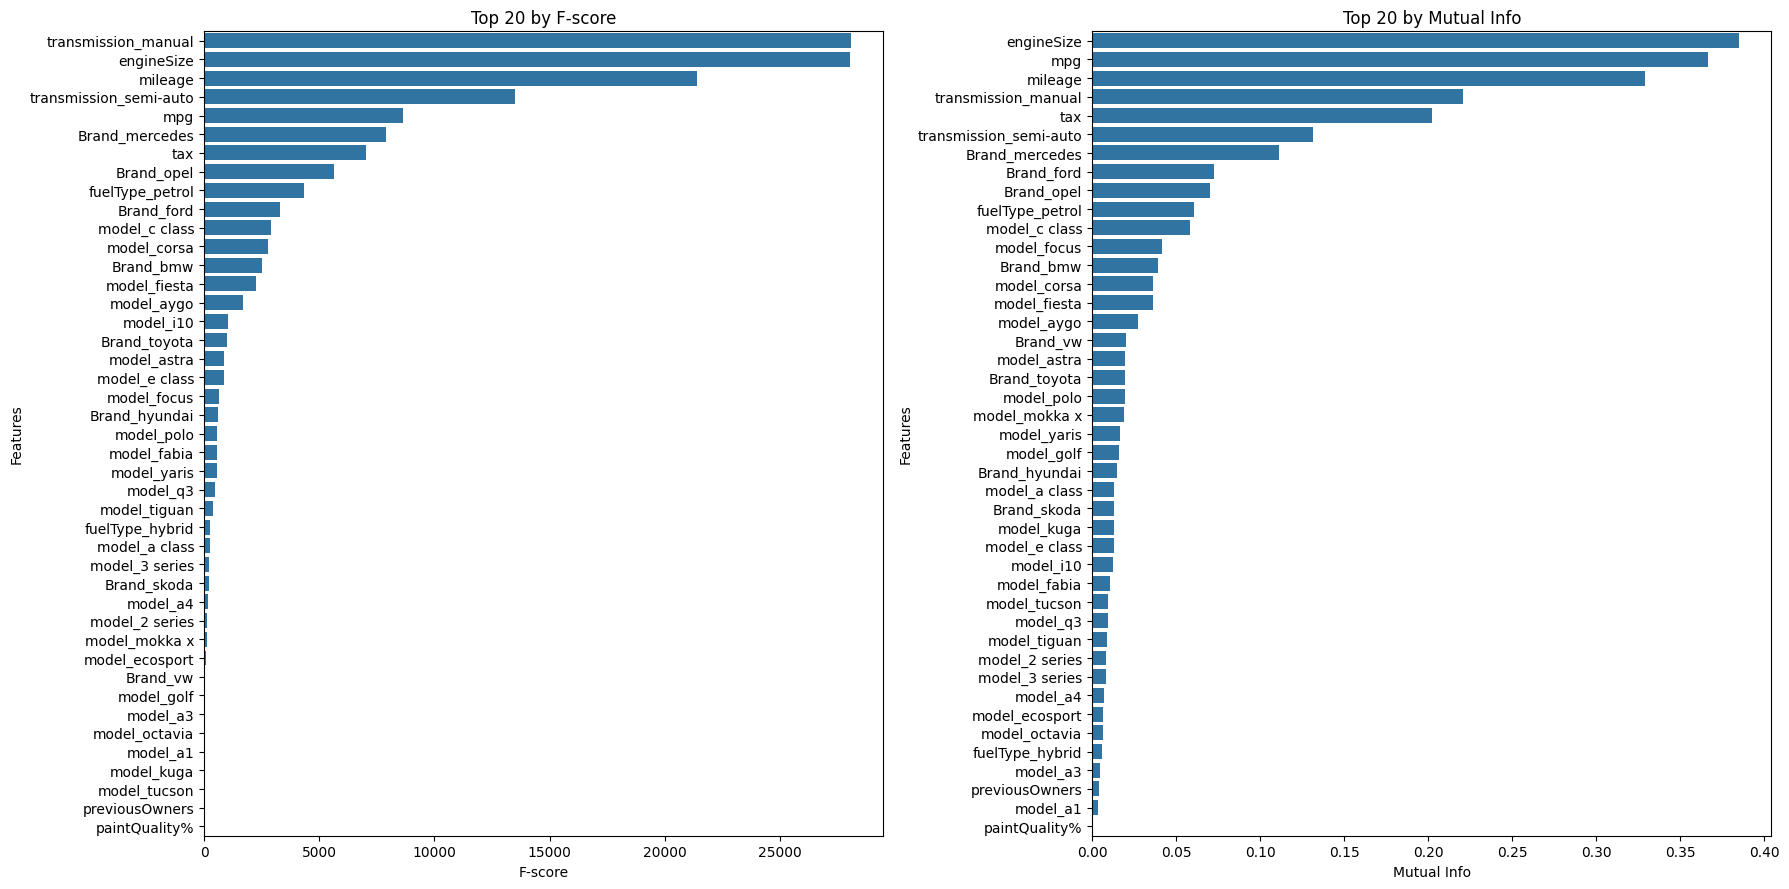

In [115]:
# Linear relationship test
selector_f = SelectKBest(score_func=f_regression, k='all').fit(X_filtered, y_train)

# Non-linear relationship test
selector_mi = SelectKBest(score_func=mutual_info_regression, k='all').fit(X_filtered, y_train)

scores_linear = pd.DataFrame({
    'feature': X_filtered.columns,
    'F_score': selector_f.scores_,
}).sort_values(by="F_score", ascending=False)

scores_non_linear = pd.DataFrame({
    'feature': X_filtered.columns,
    'Mutual_info': selector_mi.scores_
}).sort_values("Mutual_info", ascending=False)

plt.figure(figsize=(18,9))

plt.subplot(1,2,1)
sns.barplot(x='F_score', y='feature', data=scores_linear)
plt.title('Top 20 by F-score')
plt.xlabel('F-score')
plt.ylabel('Features')

plt.subplot(1,2,2)
sns.barplot(x='Mutual_info', y='feature', data=scores_non_linear)
plt.title('Top 20 by Mutual Info')
plt.xlabel('Mutual Info')
plt.ylabel('Features')

plt.tight_layout()
plt.show()


In [116]:
pd.concat(
    [scores_linear.reset_index(drop=True), 
     scores_non_linear.reset_index(drop=True)],
    axis=1
)

,feature,F_score,feature,Mutual_info
0,transmission_manual,28065.821610,engineSize,0.385015
1,engineSize,28009.169314,mpg,0.366310
2,mileage,21377.241620,mileage,0.328793
3,transmission_semi-auto,13511.465644,transmission_manual,0.220533
4,mpg,8637.523080,tax,0.202474
5,Brand_mercedes,7915.293811,transmission_semi-auto,0.131272
6,tax,7009.864674,Brand_mercedes,0.111037
7,Brand_opel,5628.174093,Brand_ford,0.072275
8,fuelType_petrol,4344.435641,Brand_opel,0.070293
9,Brand_ford,3278.983237,fuelType_petrol,0.060492


In [117]:
model2 = RandomForestRegressor(random_state=0)
model2.fit(X_filtered, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


RFECV will be used to find the optimal number of features by iteratively removing weak features until it finds the most effective subset while keeping it as small as possible. Cross-validation will be used for more robust conclusions. Only features that improve the predictive performance are going to be kept

In [118]:
rfecv = RFECV(estimator=model2, step=1, cv=KFold(5), scoring='neg_mean_absolute_error')
rfecv.fit(X_filtered, y_train)

selected = X_filtered.columns[rfecv.support_]
print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Features selected: {selected}")
print(f"Ranking: {rfecv.ranking_}")

Optimal number of features: 43
Features selected: Index(['mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%',
       'previousOwners', 'Brand_bmw', 'Brand_ford', 'Brand_hyundai',
       'Brand_mercedes', 'Brand_opel', 'Brand_skoda', 'Brand_toyota',
       'Brand_vw', 'model_2 series', 'model_3 series', 'model_a class',
       'model_a1', 'model_a3', 'model_a4', 'model_astra', 'model_aygo',
       'model_c class', 'model_corsa', 'model_e class', 'model_ecosport',
       'model_fabia', 'model_fiesta', 'model_focus', 'model_golf', 'model_i10',
       'model_kuga', 'model_mokka x', 'model_octavia', 'model_polo',
       'model_q3', 'model_tiguan', 'model_tucson', 'model_yaris',
       'transmission_manual', 'transmission_semi-auto', 'fuelType_hybrid',
       'fuelType_petrol'],
      dtype='object')
Ranking: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1]


LassoCV will be used as it forces weak coefficients to zero through an L1 regularization penalty. This simplifies linear models, handles multicollinearity well and produces sparse, interpretable solutions

In [119]:
lasso_reg = LassoCV()
lasso_reg.fit(X_filtered, y_train)

coef = pd.Series(lasso_reg.coef_, index = X_filtered.columns)
coef.sort_values()

mileage                  -1.302486
Brand_opel               -0.481136
Brand_hyundai            -0.424905
Brand_ford               -0.395136
mpg                      -0.372252
model_aygo               -0.311546
Brand_toyota             -0.306660
model_i10                -0.259640
Brand_skoda              -0.258226
model_yaris              -0.236819
model_corsa              -0.228616
Brand_vw                 -0.204994
model_fabia              -0.195567
model_polo               -0.123496
transmission_manual      -0.119630
model_a1                 -0.116968
fuelType_petrol          -0.089704
model_2 series           -0.080828
Brand_bmw                -0.080597
model_3 series           -0.054096
model_a3                 -0.048659
model_a4                 -0.037501
model_a class            -0.034794
model_octavia            -0.023873
Brand_mercedes           -0.020498
model_c class            -0.013780
previousOwners            0.000000
model_e class             0.000000
paintQuality%       

Permutation Importance measures the effect of each feature on the model's performance. It doesn't capture correlation or weight but the true predictive contribution while providing solid interpretability.

Tree based Feature importance focuses on reducing impurity across decision trees

In [120]:
perm = permutation_importance(model2, X_filtered, y_train, n_repeats=5, random_state=42)
importance = pd.Series(perm.importances_mean, index=X_filtered.columns).sort_values(ascending=False)
print(importance)

mileage                   0.487437
engineSize                0.410174
transmission_manual       0.162840
mpg                       0.146397
tax                       0.101341
Brand_opel                0.079277
Brand_ford                0.038197
Brand_mercedes            0.030724
paintQuality%             0.019894
fuelType_petrol           0.018736
model_focus               0.013943
previousOwners            0.009956
model_corsa               0.009103
Brand_hyundai             0.008875
Brand_vw                  0.008106
model_polo                0.005891
Brand_bmw                 0.005877
Brand_toyota              0.005586
model_c class             0.004268
model_fiesta              0.004084
Brand_skoda               0.003899
transmission_semi-auto    0.003491
model_a3                  0.003077
model_yaris               0.003040
model_aygo                0.002994
model_astra               0.002821
model_kuga                0.002247
model_a1                  0.002195
model_fabia         

In [121]:
feature_importance = pd.DataFrame({'Feature': X_filtered.columns, 'Importance': model2.feature_importances_})
print(feature_importance.sort_values(by='Importance', ascending=False))

                   Feature  Importance
39     transmission_manual    0.316063
0                  mileage    0.262875
3               engineSize    0.183327
2                      mpg    0.061965
1                      tax    0.044109
4            paintQuality%    0.017759
10              Brand_opel    0.015337
9           Brand_mercedes    0.012620
28             model_focus    0.008074
5           previousOwners    0.008023
7               Brand_ford    0.007991
42         fuelType_petrol    0.005351
23             model_corsa    0.005052
13                Brand_vw    0.003420
8            Brand_hyundai    0.003325
38             model_yaris    0.003308
12            Brand_toyota    0.003186
21              model_aygo    0.002550
18                model_a3    0.002430
27            model_fiesta    0.002364
6                Brand_bmw    0.002351
34              model_polo    0.002279
11             Brand_skoda    0.001993
17                model_a1    0.001918
30               model_i1

In summary:
- Filters Methods  clean the noise
- Wrappers (RFECV) find efficient subsets
- Embedded and permutation methods give explainability and confirmation of what the model truly uses.

Feature Selection Results

The following features are below 0.01 in importance, regarding our permutation and tree-based feature importance methods, meaning they are weak contributors:

| Feature             | F_score | Mutual_info |  Lasso | Permutation | Feature Importance | RFECV Rank |
| :------------------ | ------: | ----------: | -----: | ----------: | -----------------: | ---------: |
| **Brand_bmw**       | 2503.44 |     0.03759 | -0.081 |      0.0059 |             0.0024 |          1 |
| **Brand_toyota**    | 1015.98 |     0.01905 | -0.307 |      0.0056 |             0.0032 |          1 |
| **Brand_skoda**     |  198.55 |     0.01036 | -0.258 |      0.0039 |             0.0020 |          1 |
| **Brand_vw**        |  115.97 |     0.01909 | -0.205 |      0.0081 |             0.0034 |          1 |
| **Brand_hyundai**   |  621.26 |     0.01809 | -0.425 |      0.0089 |             0.0033 |          1 |
| **model_yaris**     |  466.87 |      0.0029 | -0.237 |      0.0030 |             0.0033 |          1 |
| **model_corsa**     | 2799.49 |      0.0091 | -0.229 |      0.0091 |             0.0051 |          1 |
| **model_fabia**     |  573.69 |      0.0021 | -0.196 |      0.0021 |             0.0012 |          1 |
| **model_polo**      |  574.39 |      0.0059 | -0.123 |      0.0059 |             0.0023 |          1 |
| **model_a1**        |  159.13 |      0.0022 | -0.117 |      0.0022 |             0.0019 |          1 |
| **model_a3**        |  220.83 |      0.0031 | -0.049 |      0.0031 |             0.0024 |          1 |
| **model_a4**        |  171.78 |      0.0006 | -0.037 |      0.0006 |             0.0005 |          1 |
| **model_a class**   |  256.45 |      0.0013 | -0.035 |      0.0013 |             0.0011 |          1 |
| **model_2 series**  |  138.22 |      0.0011 | -0.081 |      0.0011 |             0.0008 |          1 |
| **model_3 series**  |  235.65 |      0.0013 | -0.054 |      0.0013 |             0.0010 |          1 |
| **model_e class**   |  203.45 |      0.0010 |  0.000 |      0.0010 |             0.0007 |          1 |
| **model_ecosport**  |   89.73 |      0.0007 |  0.070 |      0.0007 |             0.0007 |          1 |
| **model_octavia**   |  208.79 |      0.0013 | -0.024 |      0.0013 |             0.0012 |          1 |
| **model_q3**        |  462.72 |      0.0014 |  0.014 |      0.0014 |             0.0017 |          1 |
| **model_tiguan**    |  409.96 |      0.0007 |  0.112 |      0.0007 |             0.0005 |          1 |
| **model_tucson**    |  205.59 |      0.0017 |  0.151 |      0.0017 |             0.0009 |          1 |
| **model_mokka x**   |  128.22 |      0.0014 |  0.043 |      0.0014 |             0.0006 |          1 |
| **model_astra**     |  853.39 |     0.01904 |  0.008 |      0.0028 |             0.0017 |          1 |
| **fuelType_hybrid** |  442.43 |      0.0082 |  0.257 |      0.0018 |             0.0014 |          1 |


They show low linear and nonlinear dependence with the target variable — meaning that statistically, their variation isn’t strongly related to target variation.
When considering Lasso, only one of these features has a coefficient equal to zero, but their magnitudes are mostly low, and RFECV retains the full feature set as optimal. These results signify that while these features do not add significantly to the model's prediction power, they also do not hurt performance noticeably so we can consider them mostly noise. Based on this results, these features shall be dropped as their contribution does not justify the added computational cost during training.

In [122]:
# Drop weak contributors based on feature selection results
weak_features = [
    'Brand_bmw','Brand_toyota','Brand_skoda','Brand_vw', 'Brand_hyundai','model_yaris','model_corsa','model_fabia','model_polo',
    'model_a1','model_a3','model_a4','model_a class','model_2 series','model_3 series','model_e class','model_ecosport','model_octavia',
    'model_q3','model_tiguan','model_tucson','model_mokka x','model_astra','fuelType_hybrid'
]

# Select final features for train, validation, and test sets
X_train_selected = X_filtered.drop(columns=weak_features, errors='ignore')
X_val_selected   = X_val_filtered.drop(columns=weak_features, errors='ignore')
x_test_selected  = x_test_filtered.drop(columns=weak_features, errors='ignore')

print(f"Selected {X_train_selected.shape[1]} features (dropped {len(weak_features)} low-importance ones).")

Selected 19 features (dropped 24 low-importance ones).


# Modeling

Models picked:
- Linear Regression: Finds a straight line (or hyperplane) that best fits the data by minimizing the difference between predicted and actual values.
- Ridge Regression: Similar to linear regression, but it adds a small penalty to large coefficients so the model doesn’t rely too heavily on any one feature.
- ElasticNet: Mixes Ridge (L2) and Lasso (L1) penalties — keeps coefficients small like Ridge but can also drop unimportant ones like Lasso.
- Bayesian Ridge: Similar to Ridge, but it treats model parameters as probabilities, giving you uncertainty estimates for predictions.
- Huber Regressor: Acts like linear regression for normal points but ignores large errors from outliers so they don’t distort the model.
- RANSAC: Builds many small models using random subsets of data and picks the one that best fits the majority, ignoring outliers.
- Theil-Sen: Calculates the median slope between all pairs of points — making it very stable when the data has noise or outliers.
- Decision Tree: Splits data step-by-step into smaller groups based on feature values, learning simple rules to make predictions.
- Random Forest: Builds many decision trees on random samples of data and averages their results for better accuracy and stability.
- Extra Trees: Like Random Forest but uses more randomness when splitting data — makes training faster and reduces overfitting.
- Linear SVR: Uses support vectors (key data points) to fit a line within a “margin” that minimizes prediction error — efficient for linear or slightly nonlinear data.
- KNN (K-Nearest Neighbors): Looks at the most similar data points (neighbors) and averages their values to predict the output.
- MLP Regressor (Multi-Layer Perceptron): A simple neural network that learns patterns by passing data through layers of neurons that adjust weights to minimize errors — great for capturing complex, nonlinear relationships.

We will test these different models with really simple implementations to get a grasp of which implementations tend to perform better and them proceed with one to hyperparameter tuning.

In [127]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=0),
    "Random Forest": model2,
    "ElasticNet": ElasticNet(random_state=0),
    "Huber": HuberRegressor(),
    "Bayesian Ridge": BayesianRidge(),
    "RANSAC": RANSACRegressor(random_state=0),
    "Theil-Sen": TheilSenRegressor(random_state=0),
    "SVR": LinearSVR(random_state=0),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=0),
    "Extra Tree": ExtraTreeRegressor(random_state=0),
    "Multi-Layer Perceptron": MLPRegressor()
}

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=0)

results = []

for name, model in models.items():
    r2 = cross_val_score(model, X_train_selected, y_train, cv=kf, scoring="r2", n_jobs=-1).mean()
    mae = -cross_val_score(model, X_train_selected, y_train, cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
    rmse = np.sqrt(-cross_val_score(model, X_train_selected, y_train, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1).mean())

    results.append({
        "Model": name,
        "R-squared": r2,
        "MAE": mae,
        "RMSE": rmse
    })


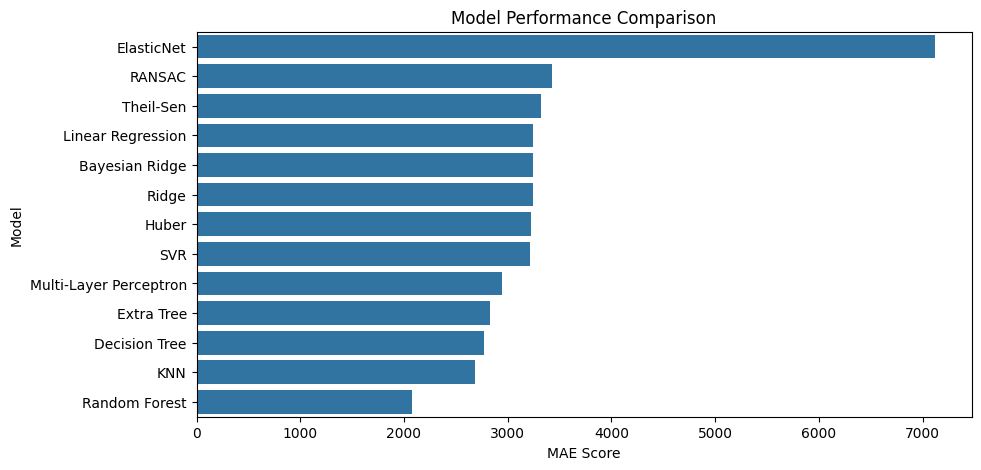

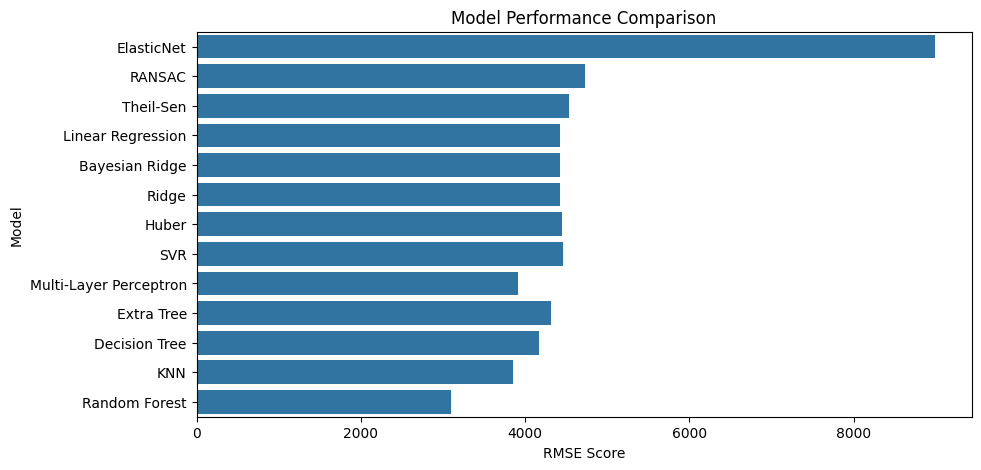

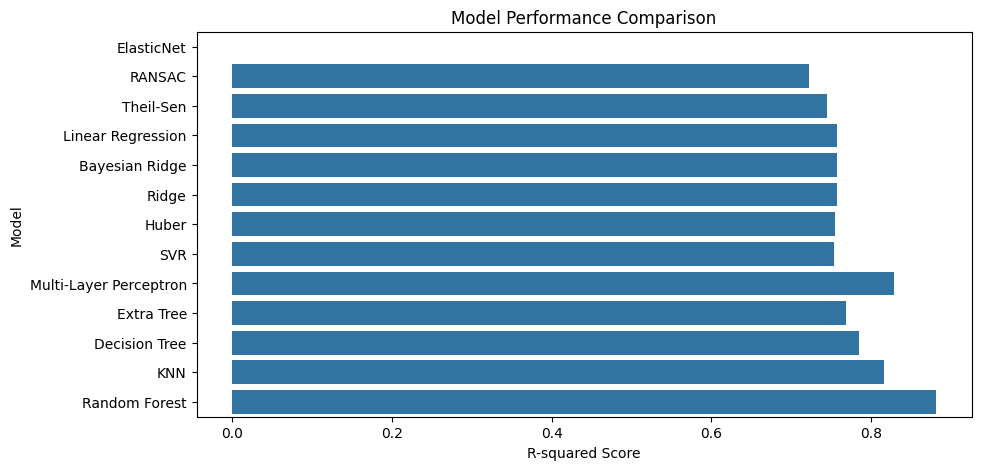

In [131]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Multiply MAE and RMSE by the average price by the average original price to restore the original scale
mean_price = np.expm1(y_train).mean()
results_df["MAE"] *= mean_price
results_df["RMSE"] *= mean_price

# Sort by MAE 
results_df = results_df.sort_values(by="MAE", ascending=True)

for metric in ['MAE', 'RMSE', 'R-squared']:
    plt.figure(figsize=(10,5))
    sns.barplot(x=metric, y='Model', data=results_df)
    plt.xlabel(f"{metric} Score")
    plt.title("Model Performance Comparison")
    plt.gca().invert_yaxis()
    plt.show()

### Hyperparameter Tuning

In [132]:
# Parameter grid
param_grid = {
    "n_estimators": [1000, 1500, 2000],
    "max_depth": [20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Grid search setup
grid_search = GridSearchCV(
    estimator=model2,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=kf,
    n_jobs=-1,
    verbose=2
)

# Fit the grid search
grid_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
8 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning\Group Project\ml_env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\elton\OneDrive\Ambiente de Trabalho\MLNotes\NOVA IMS Masters DSAA-DS\2nd Year\Machine Learning

,estimator,RandomForestR...andom_state=0)
,param_grid,"{'max_depth': [20, 40], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,1500


In [133]:
# Best model
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate on validation data
y_pred = best_rf.predict(X_val_selected)

Best Parameters: {'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1500}


# Evaluation

The evaluation metrics picked were Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R-Squared(R²). MAE was picked due to it's robustness to outliers, delivering a clear measure of the average magnitude of prediction errors. RMSE was picked as it penalizes larger errors more heavily than MAE due to squaring. Given that RMSE is sensitive to outliers, these metrics complement each other by providing a balance view of a model's performance. R² was picked due to the fact that it gives a global view of model quality, showing how well a model explains the variability of the outcome.

In [ ]:
# Convert both to original scale
y_val_exp = np.expm1(y_val)
y_pred_exp = np.expm1(y_pred)

# Compute metrics
mae_val = mean_absolute_error(y_val_exp, y_pred_exp)
rmse_val = np.sqrt(mean_squared_error(y_val_exp, y_pred_exp))
r2_val = r2_score(y_val_exp, y_pred_exp)

print(f"MAE: {mae_val:.2f}")
print(f"RMSE: {rmse_val:.2f}")
print(f"R²: {r2_val:.4f}")


MAE: 1964.83
RMSE: 3491.55
R²: 0.8746


For future iteration we will try to capture the model's performance on validation to get a representation of where our model is struggling the most (In this case it seems like the higher prices are the area where the model starts to decay in performance)

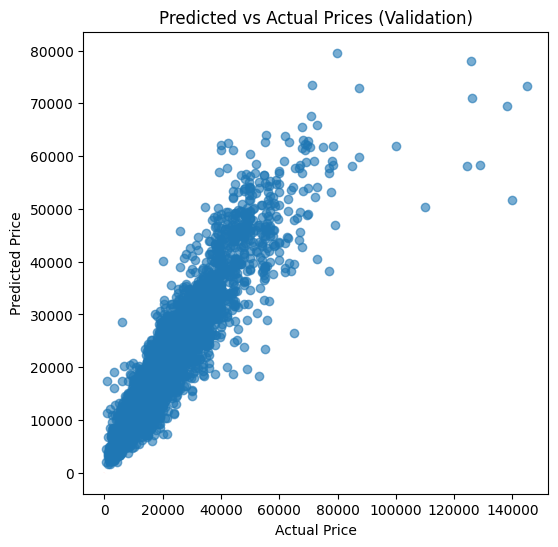

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_val_exp, y_pred_exp, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Validation)")
plt.show()

Here we analyze the performance of the different combinations of grid search and observe the 10 best combination. The objective here is to see if there is a trend whitin the parameters that results in better performance

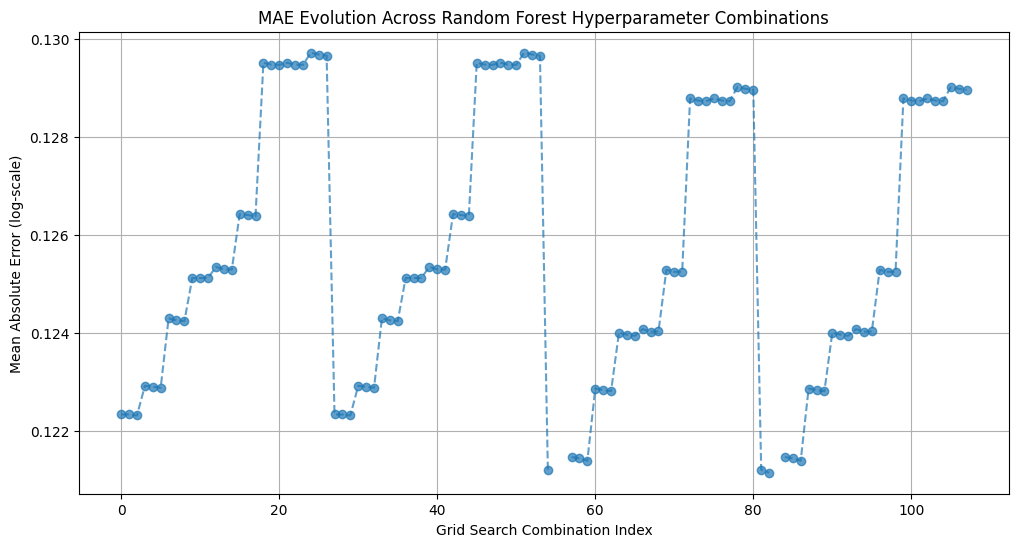

    mean_absolute_error  param_n_estimators  param_max_depth  \
82             0.121154                1500               40   
54             0.121216                1000               40   
81             0.121216                1000               40   
59             0.121398                2000               40   
86             0.121398                2000               40   
85             0.121446                1500               40   
58             0.121446                1500               40   
57             0.121474                1000               40   
84             0.121474                1000               40   
2              0.122321                2000               20   

    param_min_samples_split  param_min_samples_leaf param_max_features  
82                        2                       1               log2  
54                        2                       1               sqrt  
81                        2                       1               log2  
59 

In [ ]:
# Organize grid search results in a DataFrame
results = pd.DataFrame(grid_search.cv_results_)

results["mean_absolute_error"] = -results["mean_test_score"]

# Plot MAE evolution for each parameter
plt.figure(figsize=(12, 6))
plt.plot(results["mean_absolute_error"], marker="o", linestyle="--", alpha=0.7)
plt.xlabel("Grid Search Combination Index")
plt.ylabel("Mean Absolute Error (log-scale)")
plt.title("MAE Evolution Across Random Forest Hyperparameter Combinations")
plt.grid(True)
plt.show()


# Top 10 parameter combinations by MAE
print(results.sort_values("mean_absolute_error").head(10)[
    ["mean_absolute_error", "param_n_estimators", "param_max_depth", 
     "param_min_samples_split", "param_min_samples_leaf", "param_max_features"]
])

# Test Prediction

In [137]:
X_train_full = pd.concat([X_train_selected, X_val_selected])
y_train_full = pd.concat([y_train, y_val])

In [138]:
# Train final model on full training data
final_rf = RandomForestRegressor(**grid_search.best_params_, random_state=0, n_jobs=-1)
final_rf.fit(X_train_full, y_train_full)

,n_estimators,1500
,criterion,'squared_error'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
# Predict test set for submission
y_test_pred = np.expm1(final_rf.predict(x_test_selected))

# Deployment

In [140]:
# Build submission file
submission = pd.DataFrame({
    "carID": x_test_selected.index,
    "price": y_test_pred
})
submission.to_csv("submission.csv", index=False)
print("Submission.csv saved.")

Submission.csv saved.
